# Analysis

In [1]:
import os

dir_simul = "1_result"          # Directory for resulted simulations
dir_out = "0_analy"             # Directory for the analysis

dir_xsf_traj = "0_xsf_traj"     # Stores entire trajectory
dir_xsf = "1_xsf"               # Stores all structures
dir_im = '2_im'
dir_xsf_min_so_far = "3_min_so_far"

os.makedirs(f"{dir_out}", exist_ok=True)
os.makedirs(f"{dir_out}/{dir_xsf_traj}", exist_ok=True)
os.makedirs(f"{dir_out}/{dir_xsf}", exist_ok=True)
os.makedirs(f"{dir_out}/{dir_im}",exist_ok=True)
os.makedirs(f"{dir_out}/{dir_xsf_min_so_far}", exist_ok=True)

db_paths = [
    # (f"{dir_simul}/1_1ML_feOnMgo", 0),
    # (f"{dir_simul}/2_1ML_mgoOnFe", 1),

    (f"{dir_simul}/18_kappa2_iter100_trajNoSave_repSeedDat101", 18),
    (f"{dir_simul}/19_kappa2_iter100_trajNoSave_repSeedDat0_5x5", 19),
    (f"{dir_simul}/20_kappa2_iter100_trajNoSave_repSeedDat0_4x4", 20),

    # (f"{dir_simul}/22_latt_1", 22),
    # (f"{dir_simul}/23_latt_025", 23),
    # (f"{dir_simul}/24_latt_075", 24),
]

labels = [
    "Fe on MgO",
    "MgO on Fe",
]

# Process database

In [6]:
from scripts.process_database import process_database

for dir_path, file_idx in db_paths:
    process_database(dir_path = dir_path, 
                     file_idx = file_idx, 
                     dir_out = dir_out, 
                     dir_xsf_traj = dir_xsf_traj, 
                     dir_xsf = dir_xsf
                    )

# Graph formatting

In [2]:
colors = [
    "#FF0000",  # Pure Bold Red
    "#00FF00",  # Pure Bold Blue
]

rcParams = {
    'font.size': 12,
    #'font.family': 'sans-serif',
    "font.family": "serif",

    'axes.linewidth': 1.5,
    
    'axes.edgecolor': 'black',

    'axes.spines.top': True,
    'axes.spines.right': True,

    'xtick.direction': 'out',
    'ytick.direction': 'out',

    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 2,      # Added minor tick size
    'ytick.minor.size': 2,      # Added minor tick size
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,    # Added minor tick width
    'ytick.minor.width': 1.0,    # Added minor tick width

    'xtick.top': True,
    'ytick.right': True,         # Enabled right ticks for a "boxed" look

    'axes.grid': False,
    'legend.frameon': True,

    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
}

# e_label=r'$E_{rel}$ (eV/atom)'
e_label=r'$E_{i}-E_{glob}$ (eV/atom)'

# Vibrational entrophy

In [ ]:
import numpy as np
from ase.io import read
from ase.vibrations import Vibrations
from ase.thermochemistry import HarmonicThermo
from ase.units import kB
from gpaw import GPAW

import pandas as pd
import os

def calculate_f_vib_from_traj(traj_file, temperature, gpaw_params, output_name="vibrational_data"):
    """
    Reads a trajectory, calculates vibrational modes, 
    saves results to CSV, and returns f_vibs and g_total.
    """

    configs = read(traj_file, index=':')
    f_vib_list = []
    data_log = [] # List to store row data for CSV
    
    for i, atoms in enumerate(configs):
        calc = GPAW(**gpaw_params)
        atoms.calc = calc
        
        # Potential energy (H_0K in Yang2025)
        potential_energy = atoms.get_potential_energy()
        
        # Harmonic vibrational analysis
        name = f'vib_config_{i}'
        vib = Vibrations(atoms, name=name)
        vib.run()
        vib_energies = vib.get_energies()
        
        # Calculate F_vib(T) = E_pot + F_vibrational_contribution
        thermo = HarmonicThermo(vib_energies=vib_energies, 
                                potential_energy=potential_energy)
        
        f_i = thermo.get_helmholtz_free_energy(temperature=temperature)
        f_vib_list.append(f_i)

        data_log.append({
            'Config_Index': i,
            'Temperature_K': temperature,
            'Potential_Energy_eV': potential_energy,
            'Helmholtz_Free_Energy_F_eV': f_i
        })
        
        vib.clean()
        if os.path.exists(name): os.rmdir(name)
        
        # Cleanup vibration files
        vib.clean()

    f_vibs = np.array(f_vib_list)
    f_min = np.min(f_vibs)
    
    # Combined Free Energy G_conf+vib = -kBT * ln(sum(exp(-beta * F_vib_i)))
    beta = 1.0 / (kB * temperature)
    z_conf_vib = np.sum(np.exp(-beta * (f_vibs - f_min)))
    g_total = f_min - (kB * temperature * np.log(z_conf_vib))

    # Save individual temp
    df_configs = pd.DataFrame(data_log)
    df_configs.to_csv(f"{output_name}_configs.csv", index=False)

    df_summary = pd.DataFrame([{
        'Temperature_K': temperature,
        'G_total_ensemble_eV': g_total,
        'F_min_eV': f_min,
        'Num_Configurations': len(f_vibs)
    }])

    df_summary.to_csv(f"{output_name}_summary.csv", index=False)
    
    return f_vibs, g_total

path_traj = f"{dir_out}/{dir_xsf_traj}/traj_0.traj"

params = {
    "mode": "lcao",
    "xc": "PBE",
    "basis": "dzp",
    "txt": "result.txt",
    "mixer": {"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
    "convergence": {"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
    "kpts": {"size": (4, 4, 1), "gamma": True},
    "nbands": "nao",
    "occupations": {"name": "fermi-dirac", "width": 0.01},
    "spinpol": True,
    "symmetry": "off",
    # "maxiter": 100
}

# params = {'mode': PW(400), 'xc': 'PBE', 'txt': None}
f_values, g_sum = calculate_f_vib_from_traj(path_traj, 1500, params, output_name="5x5_island_results")

# Configurational space

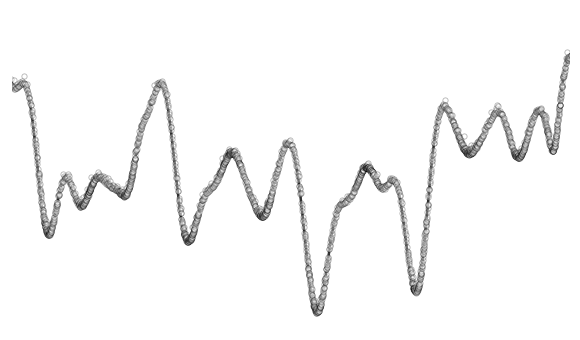

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Control parameter
complexity = 3 

# 1. Define the parameterized PES function
def complex_potential_surface(x, complexity_factor=0.5):
    y = 0.45 
    primary_valleys = [
        (2.0, 0.45, 0.7), (4.8, 0.35, 0.6), 
        (7.5, 0.40, 0.8), (10.5, 0.28, 0.5)
    ]
    local_valleys = [
        (1.2, 0.1, 0.2), (2.8, 0.08, 0.15), (4.0, 0.15, 0.25), 
        (5.5, 0.12, 0.2), (6.5, 0.2, 0.3), (8.5, 0.18, 0.25),
        (9.5, 0.1, 0.2), (11.2, 0.05, 0.1)
    ]
    for pos, depth, width in primary_valleys:
        y -= depth * np.exp(-((x - pos)**2) / (2 * width**2))
    for pos, depth, width in local_valleys:
        y -= (depth * complexity_factor) * np.exp(-((x - pos)**2) / (2 * width**2))
    y += (0.015 * complexity_factor) * np.sin(2 * np.pi * x * 1.5)
    return y

# 2. Sampling
x_range = np.linspace(0.2, 12, 1500)
x_minima = [1.2, 2.0, 2.8, 4.0, 4.8, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.2]
x_extra = [np.random.normal(xm, 0.12, 100) for xm in x_minima]
X_eigen = np.sort(np.concatenate([x_range] + x_extra))

# 3. Apply Energies and Normalize
raw_energies = complex_potential_surface(X_eigen, complexity) + np.random.exponential(0.006, len(X_eigen))
offset = np.min(raw_energies)
energies = raw_energies - offset

# 4. Generate Smooth Line Data
x_line = np.linspace(0.5, 11.5, 1000)
y_line = complex_potential_surface(x_line, complexity) - offset

# 5. Create the plot
fig, ax = plt.subplots(figsize=(5, 3), dpi=120)

# Clean scatter
ax.scatter(X_eigen, energies, s=10, facecolors='white', edgecolors='black', 
            linewidth=0.5, alpha=0.3, zorder=2)

# Line Graph
ax.plot(x_line, y_line, color='black', linewidth=1.5, alpha=0.8, zorder=1)

# --- REMOVE AXIS ENTIRELY ---
ax.axis('off')

# Ensure consistent framing
ax.set_ylim(-0.05, 1.0) 
ax.set_xlim(0.5, 11.5)

plt.tight_layout()
plt.show()

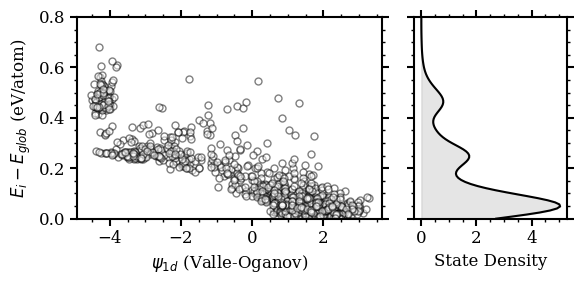

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, AutoMinorLocator 
from agox.models.descriptors.fingerprint import Fingerprint
from scipy.stats import gaussian_kde
from agox.databases import Database
from ase.io import read

structures = read(f"{dir_out}/{dir_xsf_traj}/traj_24.traj", index=':')

raw_energies, valid_structures = [], []
for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        valid_structures.append(atoms)
    except: continue 

num_atoms = len(valid_structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
# energies = (np.array(raw_energies) - min(raw_energies))

fp_instance = Fingerprint.from_atoms(valid_structures[0])
data = np.array([fp_instance.create_features(s).flatten() for s in valid_structures])

X_centered = data - np.mean(data, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
evals, evecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(evals)[::-1]
X_eigen = X_centered @ evecs[:, idx[0]]


min_x, max_x = -4, 4
min_e, max_e = 0.0, 0.8
# Target Style Parameters from Memory
# min_x, max_x = min(X_eigen), max(X_eigen)
# min_e, max_e = min(energies), max(energies)
xticks = np.round(np.linspace(min_x, max_x, 5), 0)
eticks = np.round(np.linspace(min_e, max_e, 5), 1)

energy_grid = np.linspace(min_e, max_e, 100)

plt.rcParams.update(rcParams)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), sharey=True, 
                               gridspec_kw={'width_ratios': [2, 1]})

# Scatter Plot of raw data on ax1
ax1.scatter(X_eigen, energies, s=25, facecolors='white', edgecolors='black', 
            linewidth=1.0, alpha=0.5, zorder=2)

# Raw State Density on ax2 (Calculated from actual energy distribution)
kde = gaussian_kde(energies)
density = kde.evaluate(energy_grid)
ax2.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
ax2.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.2)

# Ticks and Labels
ax1.set_xlabel(r'$\psi_{1d}$ (Valle-Oganov)')
ax1.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)')
# ax1.set_xlim(min_x, max_x)
ax1.set_ylim(min_e, max_e)
# ax1.set_xticks(xticks)
ax1.set_yticks(eticks)
ax1.tick_params(labelsize=12)
# ax1.xaxis.set_minor_locator(FixedLocator((xticks[:-1] + xticks[1:]) / 2))
# ax1.yaxis.set_minor_locator(FixedLocator((eticks[:-1] + eticks[1:]) / 2))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

ax2.set_xlabel('State Density')
ax2.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

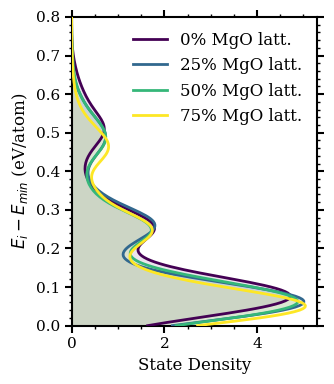

In [17]:
import numpy as np
from scipy.stats import gaussian_kde
from ase.io import read

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

dir_path = f"{dir_out}/{dir_xsf_traj}"
traj_files = [ "traj_19.traj", "traj_22.traj", "traj_23.traj", "traj_24.traj"] 
legend_labels = ["0% MgO latt.", "25% MgO latt.", "50% MgO latt.", "75% MgO latt."]

colors = plt.cm.viridis(np.linspace(0, 1, len(traj_files)))

min_e, max_e = 0.0, 0.8
energy_grid = np.linspace(min_e, max_e, 200)
fig, ax = plt.subplots(figsize=(3.5, 4))

for i, filename in enumerate(traj_files):
    try:
        full_path = f"{dir_path}/{filename}"
        structures = read(full_path, index=':')

        raw_energies = []
        for atoms in structures:
            try:
                raw_energies.append(atoms.get_potential_energy())
            except:
                continue
        
        if not raw_energies:
            continue
            
        num_atoms = len(structures[0])
        energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms

        kde = gaussian_kde(energies)
        density = kde.evaluate(energy_grid)
        label = filename.replace('.traj', '')

        ax.plot(density, energy_grid, color=colors[i], lw=2, label=legend_labels[i], zorder=4)
        ax.fill_betweenx(energy_grid, 0, density, color=colors[i], alpha=0.1)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

ax.set_ylim(min_e, max_e)
ax.set_xlim(0, None)  # Starts density at 0

ax.set_ylabel(r'$E_{i}-E_{min}$ (eV/atom)', fontsize=12)
ax.set_xlabel('State Density', fontsize=12)

ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(labelsize=11)

ax.legend(frameon=False, loc='upper right')
# ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()




# Island height

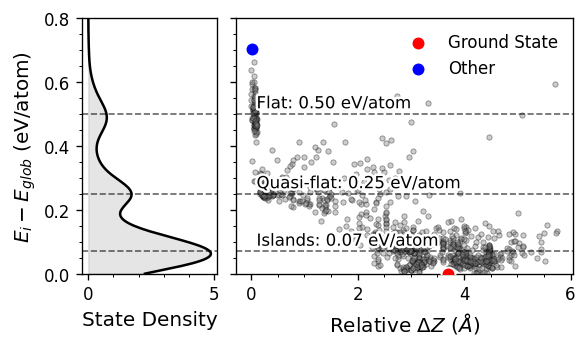

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects  # Required for the white outline
from ase.io import read
from scipy.stats import gaussian_kde

# --- Data Preparation ---
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_23.traj", index=':')
raw_energies, z_height_spans = [], []

for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        z_pos = atoms.get_positions()[:, 2]
        z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue

num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies))/num_atoms
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)

# --- Structural Limits (Horizontal on this graph) ---
limits = {
    "Islands": 0.07,
    "Quasi-flat": 0.25,
    "Flat": 0.50
}

# --- KDE Calculation ---
min_e, max_e = 0.0, 0.8
energy_grid = np.linspace(min_e, max_e, 200)
kde = gaussian_kde(energies)
density = kde.evaluate(energy_grid)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 3), sharey=True, 
                               gridspec_kw={'width_ratios': [1, 2.5]}, dpi=120)

# Subplot 1: State Density (Standard Weights)
ax1.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
ax1.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.2)
ax1.set_xlabel('State Density', fontsize=12)
ax1.set_ylabel(r'$E_i - E_{glob}$ (eV/atom)', fontsize=12)

# Subplot 2: Delta Z Scatter
ax2.scatter(z_data, energies, s=10, facecolors='grey', edgecolors='black', 
            linewidth=0.5, alpha=0.4, zorder=2)

# Global Minimum Highlight
glob_idx = np.argmin(energies)
ax2.scatter(z_data[glob_idx], energies[glob_idx], s=70, facecolors='red', 
            edgecolors='white', linewidth=1.2, zorder=5, label='Ground State')

list_of_indices = np.argsort(energies)[-1]
ax2.scatter(z_data[list_of_indices], energies[list_of_indices], s=70, facecolors='blue', 
            edgecolors='white', linewidth=1.2, zorder=5, label='Other')

# --- Add Structural Limit Lines and Outlined Labels ---
for label, val in limits.items():
    # Horizontal lines across both plots
    ax1.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=10)
    ax2.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=10)
    
    # Create the horizontal text label (No bold fontweight)
    t = ax2.text(0.1, val + 0.005, f'{label}: {val:.2f} eV/atom', 
                fontsize=10, color='black', 
                verticalalignment='bottom', zorder=11)
    
    # Apply the white outline effect for readability
    t.set_path_effects([
        patheffects.withStroke(linewidth=3, foreground='white')
    ])

# Final Styling
ax2.set_xlabel(r'Relative $\Delta Z$ ($\AA$)', fontsize=12)
ax2.set_ylim(min_e, max_e)

# Standard tick styling (No bold)
for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

ax2.legend(frameon=False, loc='upper right', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.08)
plt.show()

## Find ref for dos

In [3]:
from scripts.build_mgo_stack import build_mgo_stack
from scripts.build_fe_stack import build_fe_stack
from scripts.build_heteroStruct import build_heteroStruct

from ase.build import surface, bulk
from ase.io import read, write

supercell = (5, 5, 1)
a_mgo = 4.212            
vacuum = 20           

mgo_layer_number = 1
fe_layer_number = 1

path_xsf = f"."


bulk_mgo = bulk('MgO', 'rocksalt', a=a_mgo, cubic=True)
slab_mgo = surface(bulk_mgo, (0, 0, 1), layers=1, vacuum=vacuum)
slab_fe_base = surface('Fe', (0, 0, 1), layers=1, vacuum=vacuum)

slab_mgofe = build_mgo_stack(slab_fe_base, num_layers=mgo_layer_number, vacuum=vacuum, output_path=f"{path_xsf}/slab_mgofe.xsf")
slab_mgo = slab_mgofe[[atom.symbol != 'Fe' for atom in slab_mgofe]].repeat(supercell)
slab_fe = build_fe_stack(slab_fe_base, num_layers=fe_layer_number, vacuum=vacuum, output_path=f"{path_xsf}/slab_fe.xsf").repeat(supercell)

slab_substrate = slab_mgo.copy()
slab_deposition = slab_fe.copy()
slab_heteroStruct, slab_substrate, slab_deposition, substrate_layer_heights, deposition_layer_heights = build_heteroStruct(slab_substrate, slab_deposition, output_path=f'{path_xsf}/heteroStruct.xsf')

write(f'{path_xsf}/hetero.xsf',slab_heteroStruct)

In [5]:
import pandas as pd
import numpy as np
from ase.io import read

structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies, z_height_spans = [], []

for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        z_pos = atoms.get_positions()[:, 2]
        z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue
    
num_atoms = len(structures[0])
rel_energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
rel_z = np.array(z_height_spans) - min(z_height_spans)

df = pd.DataFrame({
    'traj_index': np.arange(len(rel_energies)),
    'energy_per_atom': rel_energies,
    'z_height_rel': rel_z
})

num_bins = 10
df['energy_range'] = pd.cut(df['energy_per_atom'], bins=num_bins)

best_structures = df.sort_values('z_height_rel').groupby('energy_range', observed=True).first().reset_index()

output_file = "lowest_height_per_energy.csv"
best_structures.to_csv(output_file, index=False)

print("done")

done


In [9]:
from ase.io import read, write, Trajectory
import numpy as np

custom_struct = read('hetero.xsf')
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')

num_atoms = len(structures[0])
raw_energies = [atoms.get_potential_energy() for atoms in structures]
rel_energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms

min_energy_idx = np.argmin(rel_energies)

target_indices = [919, 789, 1075, int(min_energy_idx)]
new_traj_list = []

for idx in target_indices:
    try:
        new_traj_list.append(structures[idx])
    except IndexError:
        print(f"Warning: Index {idx} out of range for the loaded trajectory.")

new_traj_list.append(custom_struct)
output_traj_path = "selected_structures_dos.traj"
write(output_traj_path, new_traj_list)

## Find density peak

In [5]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(density)

peak_densities = density[peaks]
peak_energies = energy_grid[peaks]

sorted_indices = np.argsort(peak_densities)[::-1]
top_3_indices = sorted_indices[:3]

print("--- Top 3 Energy Peaks (Highest State Density) ---")
for i, idx in enumerate(top_3_indices):
    e_val = peak_energies[idx]
    d_val = peak_densities[idx]
    print(f"Rank {i+1}: Energy = {e_val:.4f} eV/atom (Density = {d_val:.2f})")
    
    ax1.hlines(e_val, 0, d_val, colors='red', linestyles='--', alpha=0.5)

--- Top 3 Energy Peaks (Highest State Density) ---
Rank 1: Energy = 0.0764 eV/atom (Density = 4.72)
Rank 2: Energy = 0.2533 eV/atom (Density = 1.79)
Rank 3: Energy = 0.5106 eV/atom (Density = 0.70)


## Height density

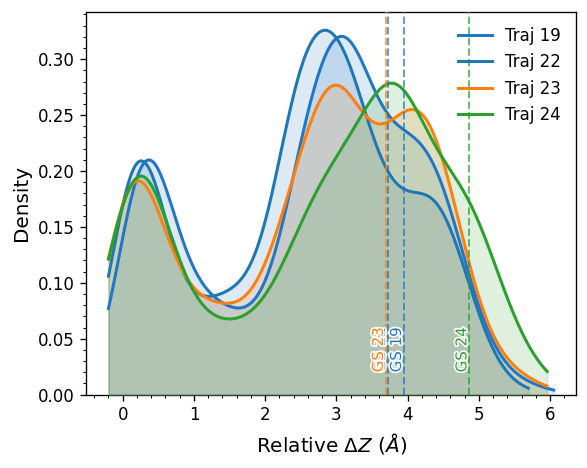

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects
from scipy.stats import gaussian_kde
from ase.io import read

# --- Configuration ---
traj_ids = [19, 22, 23, 24]  
colors = ['#1f77c5', '#1f77b4', '#ff7f0e', '#2ca02c']  
# dir_out and dir_xsf_traj should be defined in your environment

fig, ax = plt.subplots(figsize=(5, 4), dpi=120)

# To store data for global limit calculation
all_z_data = []

for i, t_id in enumerate(traj_ids):
    # --- Data Extraction ---
    try:
        structures = read(f"{dir_out}/{dir_xsf_traj}/traj_{t_id}.traj", index=':')
    except Exception as e:
        print(f"Could not read traj_{t_id}: {e}")
        continue

    raw_energies, z_height_spans = [], []
    for atoms in structures:
        try:
            raw_energies.append(atoms.get_potential_energy())
            z_pos = atoms.get_positions()[:, 2]
            z_height_spans.append(z_pos.max() - z_pos.min())
        except: continue

    num_atoms = len(structures[0])
    energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
    z_data = np.array(z_height_spans)
    z_data = z_data - min(z_data)

    # --- KDE Calculation ---
    # Create a smooth grid for plotting
    z_grid = np.linspace(z_data.min() - 0.2, z_data.max() + 0.2, 300)
    kde = gaussian_kde(z_data)
    density = kde.evaluate(z_grid)

    # --- Plotting the KDE ---
    ax.plot(z_grid, density, color=colors[i], lw=1.8, label=f'Traj {t_id}', zorder=4)
    ax.fill_between(z_grid, 0, density, color=colors[i], alpha=0.15, zorder=3)

    # --- Ground State Marker ---
    glob_idx = np.argmin(energies)
    gs_z = z_data[glob_idx]
    
    # Vertical line for GS
    ax.axvline(gs_z, color=colors[i], linestyle='--', lw=1.2, alpha=0.7, zorder=5)
    
    # Outlined Ground State Label
    # y_pos is staggered slightly for each trajectory
    y_pos = ax.get_ylim()[1] if i == 0 else plt.gca().get_ylim()[1] 
    # Update y_pos logic to use current max height
    t = ax.text(gs_z, 0.02, f'GS {t_id}', color=colors[i], fontsize=9, 
                rotation=90, ha='right', va='bottom', zorder=10)
    t.set_path_effects([patheffects.withStroke(linewidth=2, foreground='white')])

# --- Final Styling ---
ax.set_xlabel(r'Relative $\Delta Z$ ($\AA$)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

# Ensure Y-axis starts at 0
ax.set_ylim(0, None)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.legend(frameon=False, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Calc probability dist

In [32]:
def calculate_boltzmann_probs(energies, kde_model, T):
    """
    Calc Pi = g_(E)exp(-A/kbT) / Z
    """

    rho_i = kde_model.evaluate(energies) + 1e-15

    relative_e = energies - np.min(energies)
    exponent = -relative_e / (kb * T)

    weights = np.exp(exponent)
    Z = np.sum(weights)

    return rho_i * weights / Z

/tmp/ipykernel_896870/3210701987.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))


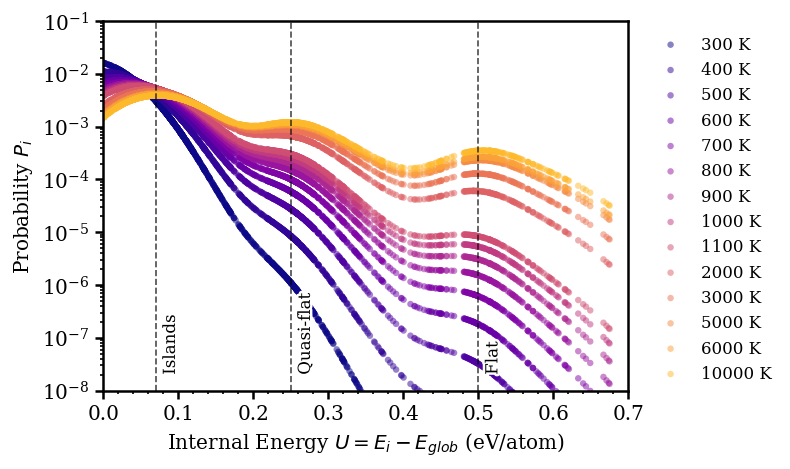

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects # Required for the outline
from ase.io import read
from scipy.stats import gaussian_kde

# --- Constants & Setup ---
kb = 8.6173e-5 # eV/K
temps = [300, 400, 500, 600, 700, 800, 900, 1000, 1100, 2000, 3000, 5000, 6000, 10000]
colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))

# Load and normalize energies
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies = [atoms.get_potential_energy() for atoms in structures]
num_atoms = len(structures[0])

# Defining U = E_i - E_glob (normalized per atom)
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
kde = gaussian_kde(energies)

# --- Define Structural Limits ---
limits = {
    "Islands": 0.07,
    "Quasi-flat": 0.25,
    "Flat": 0.50
}

# --- Plotting ---
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

# 1. Plot Boltzmann Probabilities for each Temp
for T, color in zip(temps, colors_plasma):
    probs = calculate_boltzmann_probs(energies, kde, T)
    
    peak_idx = np.argmax(probs)
    peak_energy = energies[peak_idx]
    
    note_label = f'{T} K'
    ax.scatter(energies, probs, color=color, s=15, alpha=0.5, 
               edgecolors='none', label=note_label)

# 2. Add Structural Limit Vertical Lines (Black) with Outlined Text
y_text_pos = 2e-8 

for label, val in limits.items():
    ax.axvline(x=val, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=10)
    
    # Create the text object
    t = ax.text(val + 0.008, y_text_pos, f'{label}', 
                rotation=90, verticalalignment='bottom', fontsize=10, 
                color='black', zorder=11)
    
    # Apply the white outline (path effect)
    t.set_path_effects([
        patheffects.withStroke(linewidth=3, foreground='white')
    ])

# --- Final Styling ---
ax.set_xlabel(r'Internal Energy $U = E_i - E_{glob}$ (eV/atom)', fontsize=12)
ax.set_ylabel(r'Probability $P_i$', fontsize=12)
ax.set_yscale('log')

ax.set_xlim(0.0, 0.7)
ax.set_ylim(1e-8, 1e-1)

ax.xaxis.set_minor_locator(AutoMinorLocator())

# --- Legend Outside ---
ax.legend(frameon=False, 
          fontsize=10, 
          loc='upper left', 
          bbox_to_anchor=(1.02, 1))

plt.subplots_adjust(right=0.75) 

plt.show()

/tmp/ipykernel_896870/3051668743.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))
/tmp/ipykernel_896870/3051668743.py:69: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), frameon=False, fontsize=8)


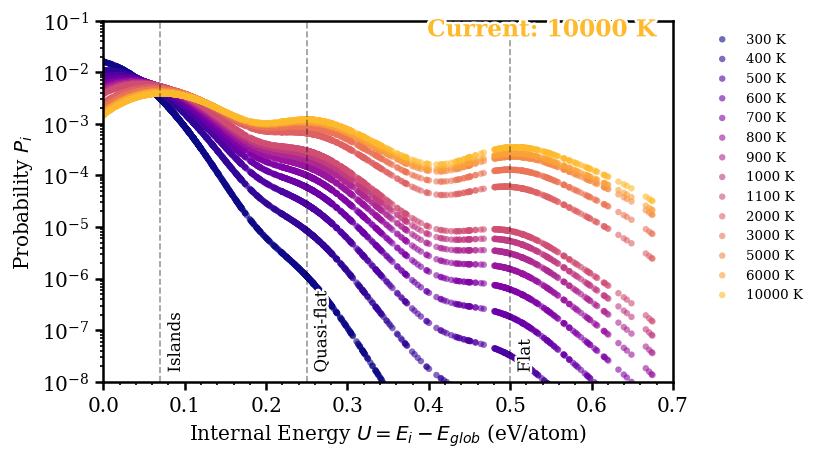

Stacking animation saved to: 0_analy/temp_stacking_evolution.gif


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects
from matplotlib.animation import FuncAnimation, PillowWriter
from ase.io import read
from scipy.stats import gaussian_kde

# --- Data Preparation ---
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies = [atoms.get_potential_energy() for atoms in structures]
num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
kde = gaussian_kde(energies)

temps = [300, 400, 500, 600, 700, 800, 900, 1000, 1100, 2000, 3000, 5000, 6000, 10000]
colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))

limits = {"Islands": 0.07, "Quasi-flat": 0.25, "Flat": 0.50}

# --- Setup Figure for Animation ---
# Increased bottom margin via subplots_adjust later to prevent cutting
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

def init():
    ax.clear()
    ax.set_xlabel(r'Internal Energy $U = E_i - E_{glob}$ (eV/atom)', fontsize=12)
    ax.set_ylabel(r'Probability $P_i$', fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(0.0, 0.7)
    ax.set_ylim(1e-8, 1e-1)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    
    # Static Structural Lines
    # Moved text pos slightly up to ensure it's within the axis box
    for label, val in limits.items():
        ax.axvline(x=val, color='black', linestyle='--', linewidth=1, alpha=0.4)
        t = ax.text(val + 0.008, 1.5e-8, label, rotation=90, va='bottom', fontsize=10)
        t.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])
    
    plt.tight_layout()
    return []

def update(frame):
    # We NO LONGER remove ax.collections to allow stacking
    
    # Remove ONLY the previous large temperature header text
    for text in ax.texts:
        if "HEADER_TEMP" in text.get_label():
            text.remove()

    T = temps[frame]
    color = colors_plasma[frame]
    
    # Calculate probabilities
    probs = calculate_boltzmann_probs(energies, kde, T)
    
    # Add new scatter (stacking on top of old ones)
    ax.scatter(energies, probs, color=color, s=15, alpha=0.6, 
               edgecolors='none', label=f'{T} K')
    
    # Floating Header Temperature Label (Current frame indicator)
    temp_text = ax.text(0.68, 0.5e-1, f'Current: {T} K', fontsize=14, color=color, 
                        fontweight='bold', ha='right', label="HEADER_TEMP")
    temp_text.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])
    
    # Optional: Update legend to show progress
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), frameon=False, fontsize=8)
    
    return []

# --- Create and Save Animation ---
# Note: repeat=True will keep the gif looping
ani = FuncAnimation(fig, update, frames=len(temps), init_func=init, blit=False)

# Adjust plot to make room for labels and legend
plt.subplots_adjust(bottom=0.15, right=0.8)

# Save as GIF
writer = PillowWriter(fps=3) 
save_path = f"{dir_out}/temp_stacking_evolution.gif"
ani.save(save_path, writer=writer)

plt.show()
print(f"Stacking animation saved to: {save_path}")

# Visual struct

```
[Flattest & Near Flattest]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
1331       | 0.003678        | 3.322588  
1332       | 0.000951        | 3.322588  
1118       | 0.000306        | 3.817907  

[Median & Near Median]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
1130       | 0.000579        | 3.883843  
1116       | 0.000158        | 3.895890  
1123       | 0.000370        | 3.868454  

[Peak & Near Peak]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
1109       | 0.000000        | 3.948085  
1108       | 0.003532        | 3.933768  
1113       | 0.001481        | 3.909034  
```

/teamspace/studios/this_studio/scripts/plot_structure.py:181: SyntaxWarning: invalid escape sequence '\D'
  cbar_label=r'$\Delta z$ ($\AA$)',


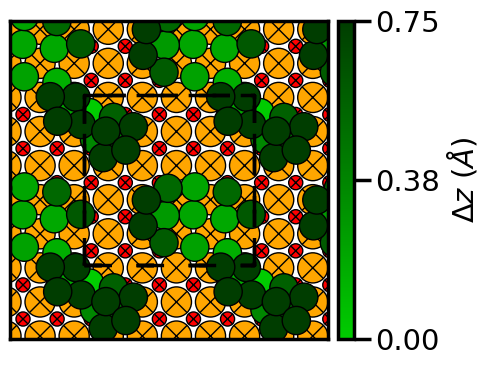

In [3]:
from ase.io import read
from scripts.plot_structure import plot_structure
import numpy as np

# cell_offset = np.array([0, 8.7, 0])  # 22
# cell_offset = np.array([8.7, 8.7, 0]) # 23
cell_offset = np.array([5, 5, 0]) # 24

# cell_offset = np.array([10, 10, 0])  
# structs = read(f"{dir_out}/{dir_xsf}/20/struct_1577.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/18/struct_259.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/19/struct_1109.xsf")
# atom_center = structs.get_positions().mean(axis=0)
# structs.rotate(90, 'z', center=atom_center)

# structs = read(f"{dir_out}/{dir_xsf}/19/struct_919.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/19/struct_1124.xsf")
structs = read(f"{dir_out}/{dir_xsf}/19/struct_1255.xsf")
atom_center = structs.get_positions().mean(axis=0)
structs.rotate(90, 'z', center=atom_center) #90

"""
734        | 0.447726        | 0.150352 
1040       | 0.500796        | 0.128013 
1237       | 0.549279        | 0.160606  

528        | 0.203660        | 1.223577 
748        | 0.247753        | 0.363083  
947        | 0.304457        | 0.445915 

1109| 0.0
56         | 0.098679        | 3.001485  
1268       | 0.181848        | 5.850280 
"""

# structs = read(f"{dir_out}/{dir_xsf}/23/struct_391.xsf")

# structs = read(f"{dir_out}/{dir_xsf}/22/struct_798.xsf")
# atom_center = structs.get_positions().mean(axis=0)
# structs.rotate(90, 'z', center=atom_center)

# structs = read(f"{dir_out}/{dir_xsf}/24/struct_889.xsf")

plot_structure(
    structs, 
    # axis_off = True,
    # plane='xz+',
    plane='xy+',
    figsize=(5, 5),
    # figsize=(4, 4),
    # figsize=(4.1, 4.1),
    # figsize=(4.2, 4.2),

    cell_offset = cell_offset,
    repeat=3,
    constraint_symbols=['Mg', 'O'], 
    height_darken_symbols=['Fe'],  
    
    add_cell = True,
    radius_factor = 0.9,
    linewidths = 2.5,
    cbar_label=r'$\Delta z$ ($\AA$)',
    show_colorbar = True,
    fontsize = 21,
    max_cbar = 0.75,
    darken_factor=0.7,   # 0.0 = original color, 1.0 = goes toward black
    num_ticks=3          # Custom number of axis values
)

## Index Finder

In [7]:
import numpy as np
from ase.io import read

target_energy = 0.254 # 0.254 # 0.5106 eV
tolerance = 0.005      # 0.005
top_n = 3   # 3          

structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies, z_height_spans = [], []

# for atoms in structures:
#     try:
#         raw_energies.append(atoms.get_potential_energy())
#         z_pos = atoms.get_positions()[:, 2]
#         z_height_spans.append(z_pos.max() - z_pos.min())
#     except Exception:
#         continue

for atoms in structures:
    try:
        symbols = np.array(atoms.get_chemical_symbols())
        fe_indices = np.where(symbols == 'Fe')[0]
        
        if len(fe_indices) > 0:
            z_fe = atoms.get_positions()[fe_indices, 2]
            
            z_height_spans.append(z_fe.max() - z_fe.min())
            raw_energies.append(atoms.get_potential_energy())
            
    except Exception as e:
        print(f"Skipping frame due to error: {e}")
        continue

num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)

energy_mask = np.abs(energies - target_energy) <= tolerance
target_indices = np.where(energy_mask)[0]

if len(target_indices) > 0:
    subset_z = z_data[target_indices]

    flat_sub_indices = np.argsort(subset_z)[:top_n] # find flattest
    idx_flat = target_indices[flat_sub_indices]

    peak_sub_indices = np.argsort(subset_z)[::-1][:top_n] # find peak height
    idx_peak = target_indices[peak_sub_indices]

    target_median_z = np.median(subset_z)
    median_diffs = np.abs(subset_z - target_median_z)
    median_sub_indices = np.argsort(median_diffs)[:top_n]
    idx_median = target_indices[median_sub_indices]

    categories = [
        ("Flattest & Near Flattest", idx_flat),
        ("Median & Near Median", idx_median),
        ("Peak & Near Peak", idx_peak)
    ]

    for label, indices in categories:
        print(f"[{label}]")
        print(f"{'Index':<10} | {'Energy (eV/at)':<15} | {'Z-Span (Å)':<10}")
        print("-" * 42)
        for idx in indices:
            # We use energies[idx] to see exactly how close it was to 0.5106
            print(f"{idx:<10} | {energies[idx]:<15.6f} | {z_data[idx]:<10.6f}")
        print()


[Flattest & Near Flattest]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
112        | 0.257703        | 0.001920  
648        | 0.258746        | 0.002053  
948        | 0.255250        | 0.004217  

[Median & Near Median]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
1153       | 0.252385        | 0.051690  
652        | 0.258127        | 0.054567  
953        | 0.257044        | 0.060828  

[Peak & Near Peak]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
1255       | 0.254888        | 2.692296  
327        | 0.253313        | 2.083342  
23         | 0.258160        | 1.525373  



# Best so far xsf

In [29]:
from scripts.write_best_so_far_xsf import write_best_so_far_xsf
from ase.io import read

trajs = read(f"{dir_out}/{dir_xsf_traj}/traj_0.traj", index=":")
all_e = [atoms.get_potential_energy() for atoms in trajectory]

write_best_so_far_xsf(trajs=trajs,
                      energies=all_e, 
                      output_dir=f"{dir_out}/{dir_xsf_min_so_far}/0")

IndexError: list index out of range

# Make snapshot

In [6]:
import os
import numpy as np
from ase.io import read
from ase.constraints import FixAtoms
from scripts.plot_structure import plot_structure

# --- 1. Selection Logic & Data Preparation ---
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies, z_height_spans = [], []

for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        z_pos = atoms.get_positions()[:, 2]
        z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue

num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)

energy_threshold = 0.25
low_energy_indices = np.where(energies < energy_threshold)[0]
n_show = 4  

if len(low_energy_indices) >= n_show:
    subset_z = z_data[low_energy_indices]
    sorted_subset_indices = np.argsort(subset_z)
    
    # Define the three distinct groups
    low_z_indices = low_energy_indices[sorted_subset_indices[:n_show]]
    high_z_indices = low_energy_indices[sorted_subset_indices[-n_show:]]
    
    mid_point = len(sorted_subset_indices) // 2
    half_n = n_show // 2
    mid_z_indices = low_energy_indices[sorted_subset_indices[mid_point - half_n : mid_point - half_n + n_show]]

    # This is the variable used by the plotting loop below
    categories = {
        "flat": low_z_indices,
        "mid": mid_z_indices,
        "tall": high_z_indices
    }
else:
    print(f"Error: Not enough structures below {energy_threshold}.")
    categories = {}

# --- 2. Automated Plotting Loop ---
output_img_dir = f"./{dir_out}/structure_images"
if not os.path.exists(output_img_dir) and categories:
    os.makedirs(output_img_dir)

for cat_prefix, idx_list in categories.items():
    for i, idx in enumerate(idx_list):
        file_path = f"{dir_out}/{dir_xsf}/19/struct_{idx}.xsf"
        
        if not os.path.exists(file_path):
            print(f"Skipping: {file_path} not found.")
            continue
            
        structs = read(file_path)
        
        # Substrate setup
        substrate_symbols = ['Mg', 'O']
        substrate_indices = [atom.index for atom in structs if atom.symbol in substrate_symbols]
        structs.set_constraint(FixAtoms(indices=substrate_indices))

        # View settings
        cell_offset = np.array([5, 5, 0])  
        save_path = f"{output_img_dir}/{cat_prefix}_{i}_idx{idx}.png"

        print(f"Generating image: {save_path}")
        plot_structure(
            structs,
            plane='yz+', # Side view to capture Delta Z evolution
            save_path=save_path,
            figsize=(5, 5),
            repeat=7,
            plot_show=False, 
            linewidths_cell=4.0,
            cell_offset=cell_offset,
            darken_factor=0.3,
            n_darken_layers=2,
        )

print("\nProcessing complete.")

Generating image: ./0_analy/structure_images/flat_0_idx851.png
Generating image: ./0_analy/structure_images/flat_1_idx734.png
Generating image: ./0_analy/structure_images/flat_2_idx839.png
Generating image: ./0_analy/structure_images/flat_3_idx500.png
Generating image: ./0_analy/structure_images/mid_0_idx898.png
Generating image: ./0_analy/structure_images/mid_1_idx73.png
Generating image: ./0_analy/structure_images/mid_2_idx887.png
Generating image: ./0_analy/structure_images/mid_3_idx361.png
Generating image: ./0_analy/structure_images/tall_0_idx1222.png
Generating image: ./0_analy/structure_images/tall_1_idx588.png
Generating image: ./0_analy/structure_images/tall_2_idx1227.png
Generating image: ./0_analy/structure_images/tall_3_idx1268.png

Processing complete.


# Energy progression

In [13]:
colors = [
    "#006400",
    "#FFA500",
    
]

rcParams = {
    'font.size': 12,
    #'font.family': 'sans-serif',
    "font.family": "serif",

    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black',

    'axes.spines.top': True,
    'axes.spines.right': True,

    'xtick.direction': 'out',
    'ytick.direction': 'out',

    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 2,      # Added minor tick size
    'ytick.minor.size': 2,      # Added minor tick size
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,    # Added minor tick width
    'ytick.minor.width': 1.0,    # Added minor tick width

    'xtick.top': False,
    'ytick.right': False,         # Enabled right ticks for a "boxed" look

    'axes.grid': False,
    'legend.frameon': True,

    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
}

# e_label=r'$E_{rel}$ (eV/atom)'
e_label=r'$E_{i}-E_{glob}$ (eV/atom)'

1_result/1_1ML_feOnMgo/1_db/db_0.db
1_result/2_1ML_mgoOnFe/1_db/db_0.db


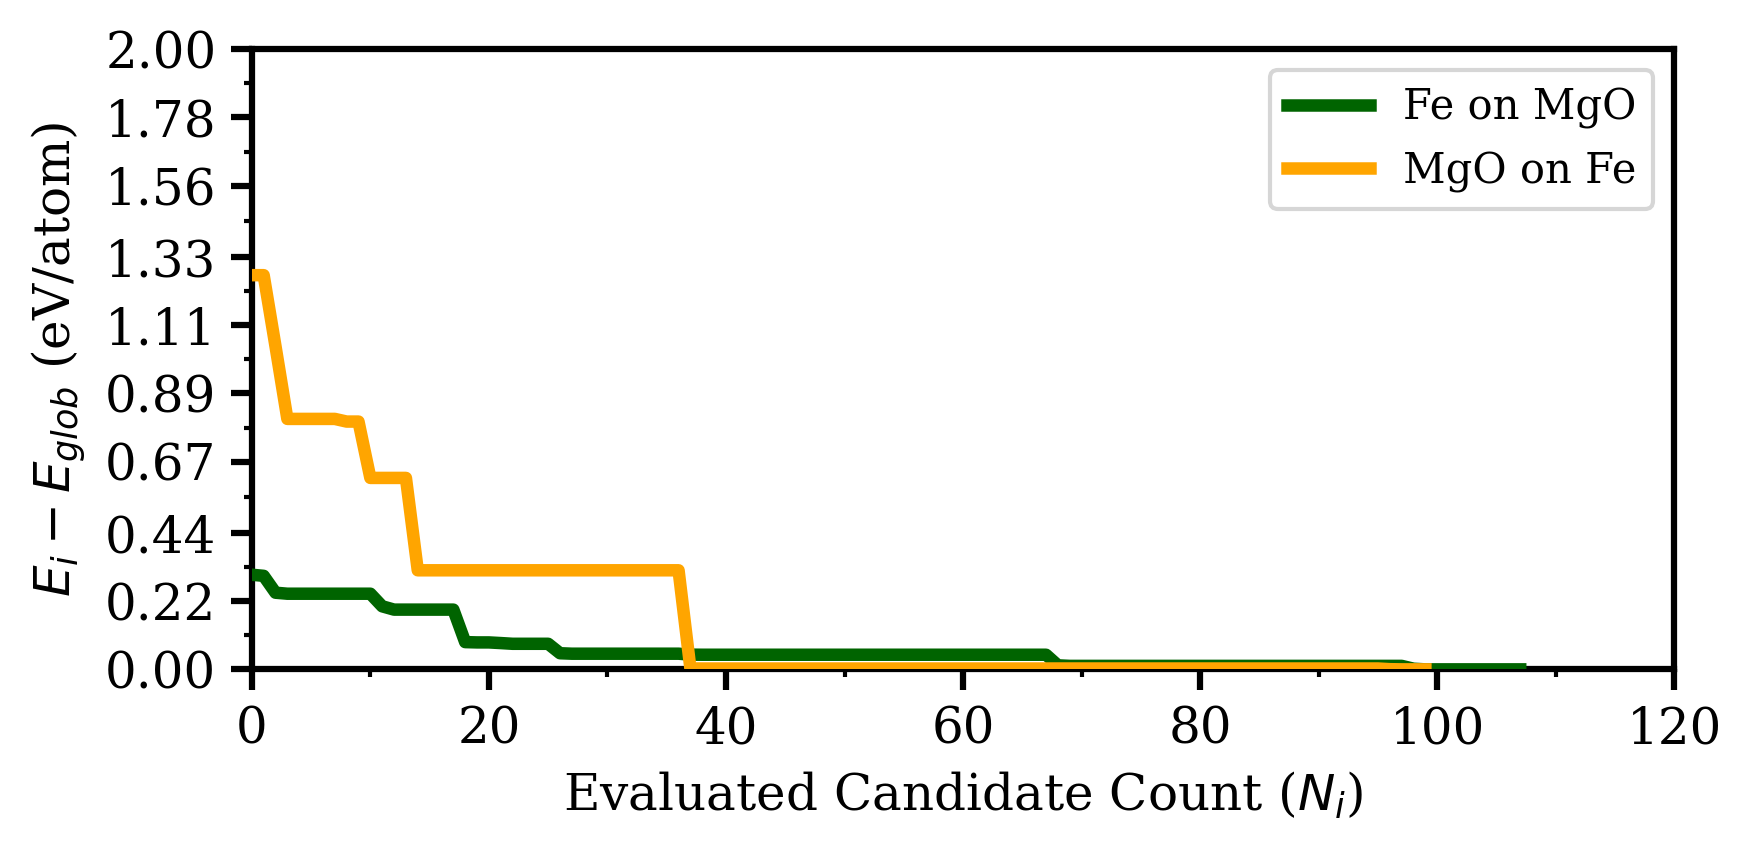

In [15]:
from scripts.plot_energy_progression import plot_energy_progression
import numpy as np

max_x = 120
max_y = 2.0

xticks = np.linspace(0, max_x, 7)
xticks = np.round(xticks).astype(int)

yticks = np.linspace(0, max_y, 10)
yticks = np.round(yticks, 2)

x_lim=(0, max_x)
y_lim=(0, max_y)


plot_energy_progression(
    db_paths,
    labels,
    dir_out,
    dir_im,

    figsize=(6, 3),

    y_label=e_label,
    x_label=r'Evaluated Candidate Count ($N_i$)',
    line_styles=['-'],

    rcParams=rcParams,
    colors=colors,

    linewidth=3.0,

    x_lim=x_lim,
    y_lim=y_lim,

    xticks = xticks,
    yticks = yticks,

    # index_skip=3,
    # add_scatter=True,
    #scale_up = 1,
)

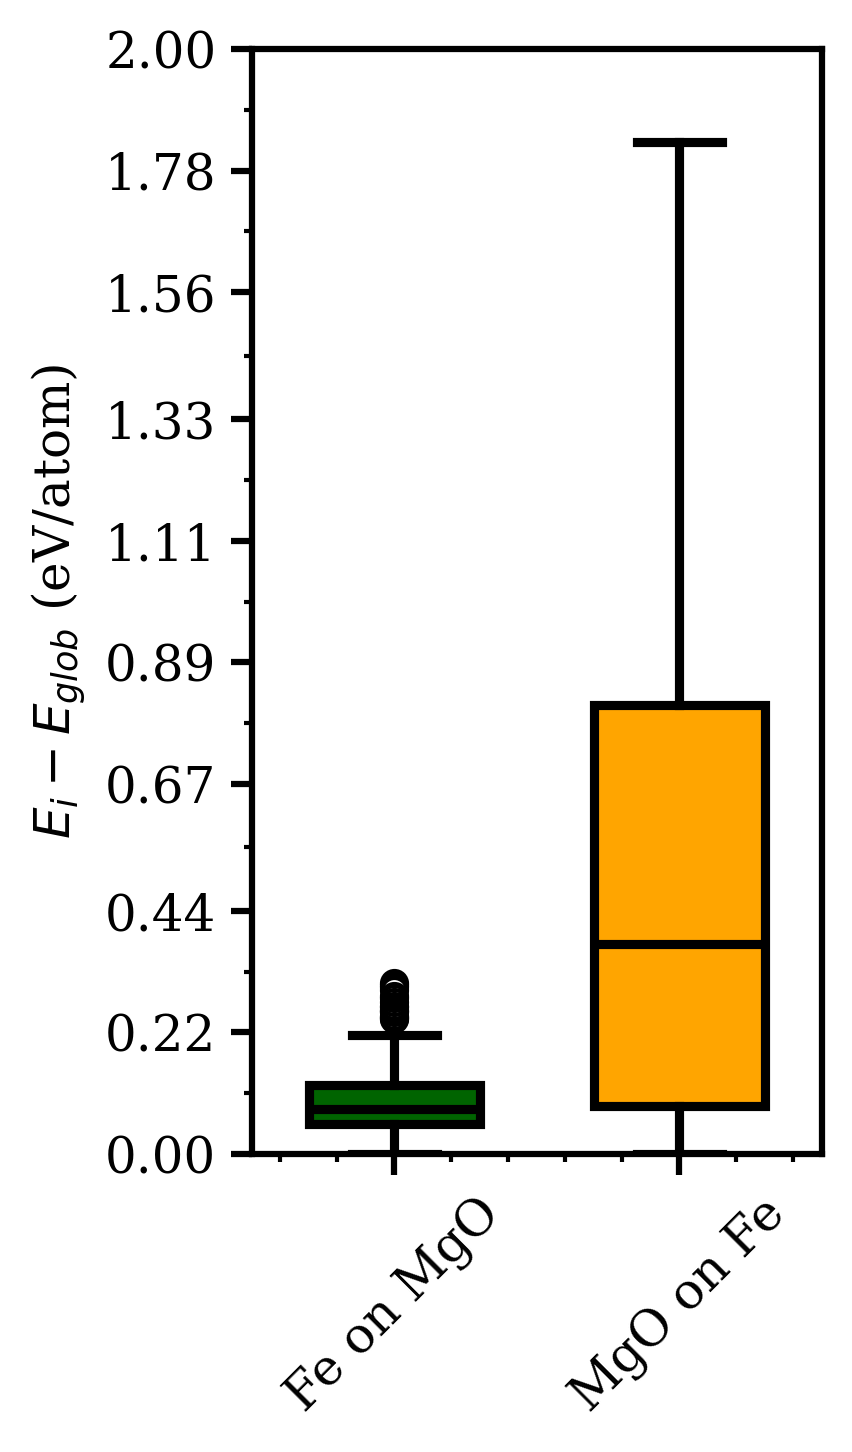

In [45]:
from scripts.plot_energy_distribution import plot_energy_distribution

max_x = 2
max_y = 2.0

xticks = np.linspace(0, max_x, 2)
xticks = np.round(xticks).astype(int)

yticks = np.linspace(0, max_y, 10)
yticks = np.round(yticks, 2)

x_lim=(0, max_x)
y_lim=(0, max_y)

plot_energy_distribution(
        db_paths,
        labels,
        dir_out,
        dir_im,
        figsize=(3, 5),
        y_label=e_label,
        x_label=None,
        colors=colors,

        # xticks = xticks,
        yticks = yticks,

        # x_lim=x_lim,
        y_lim=y_lim,
        
        plot_type="box",  # "box" or "density"
        font_family='serif',
        rcParams=rcParams,
        widths = 0.6
)

# Pca

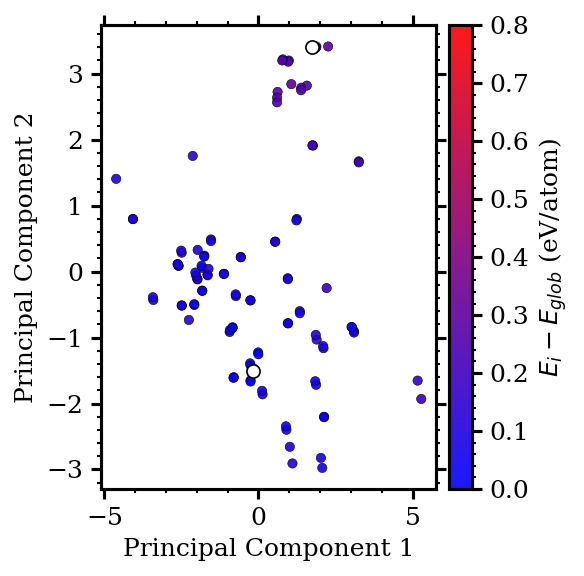

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from matplotlib.colors import LinearSegmentedColormap

from matplotlib.ticker import FixedLocator

# Plot configuration
figsize = (4, 4)
min_x, max_x = -4, 4
min_y, max_y = -2, 4
min_e, max_e = 0.0, 0.8

# Generate tick values
xticks = np.round(np.linspace(min_x, max_x, 5), 0)
yticks = np.round(np.linspace(min_y, max_y, 5), 1)
eticks = np.round(np.linspace(min_e, max_e, 10), 1)

xticks_minor = (xticks[:-1] + xticks[1:]) / 2
yticks_minor = (yticks[:-1] + yticks[1:]) / 2
eticks_minor = (eticks[:-1] + eticks[1:]) / 2

# Load database
dir_path = db_paths[0][0]
db_path = os.path.join(dir_path, "1_db", "db_0.db")
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# Extract descriptors and energies
descriptor = Fingerprint.from_atoms(traj[0])
all_features, raw_energies = [], []

for atoms in traj:
    try:
        f = descriptor.create_features(atoms)
        all_features.append(f.flatten())
        raw_energies.append(atoms.get_potential_energy())
    except Exception:
        continue 

# Process data
X = np.array(all_features)
num_atoms = len(traj[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms

# Dimension reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Initialize plot
fig, ax = plt.subplots(figsize=figsize, dpi=150)

# Create custom colormap
cmap = LinearSegmentedColormap.from_list("custom", ["#0000FF", "#FF0000"])

# Plot scatter data
sc = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], c=energies, 
    cmap=cmap, vmin=min_e, vmax=max_e, 
    s=20, alpha=0.9, edgecolors='black', linewidths=0.3
)

# Find indices for the global minimum and maximum energies
idx_min: int = np.argmin(energies)
idx_max: int = np.argmax(energies)

# Add additional scatter points for extrema in black
# Using 'X_pca' for coordinates and a distinct size/edge for visibility
ax.scatter(
    X_pca[[idx_min, idx_max], 0], 
    X_pca[[idx_min, idx_max], 1], 
    color='white',
    s=40,               # Slightly larger than the standard points
    marker='o',         # Circular marker
    edgecolors='black', # White edge to make black points pop
    linewidths=0.8,
    zorder=10           # Ensure these points are on top of the main scatter
)

# Set axis aesthetics
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
# ax.set_xlim(min_x, max_x)
# ax.set_ylim(min_y, max_y)
# ax.set_xticks(xticks)
# ax.set_yticks(yticks)
# ax.tick_params(labelsize=12)

# ax.xaxis.set_minor_locator(FixedLocator(xticks_minor))
# ax.yaxis.set_minor_locator(FixedLocator(yticks_minor))

# Configure colorbar
cbar = fig.colorbar(sc, ax=ax, shrink=1, pad=0.03)
cbar.set_label(e_label)
# cbar.set_ticks(eticks)
# cbar.ax.yaxis.set_minor_locator(FixedLocator(eticks_minor))

# Save figure
fig.tight_layout()
out_path = os.path.join(dir_out, dir_im, 'energy_landscape_pca.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

# Make graph of height

In [41]:
import matplotlib.pyplot as plt
from pathlib import Path

from agox.databases import Database

from scripts.calculate_relative_energy import calculate_relative_energy
from scripts.calculate_best_so_far import calculate_best_so_far

db_path = db_paths[0][0]
# Database loading
db_path = Path(db_path) / "1_db" / "db_0.db"
database = Database(filename=str(db_path))
trajs = database.restore_to_trajectory()

# Data Calculation
_, _, _, rel_energies = calculate_relative_energy(trajs)
best_energies, best_indices = calculate_best_so_far(rel_energies)

z_height_spans = [atoms.get_positions()[:, 2].max() - atoms.get_positions()[:, 2].min() for atoms in trajs]

In [ ]:

z_height_spans = [atoms.get_positions()[:, 2].max() - atoms.get_positions()[:, 2].min() for atoms in trajs]
plt.scatter(rel_energies_mev, z_height_spans, color=colors[0], s=20, edgecolors='black', linewidths=0.5)


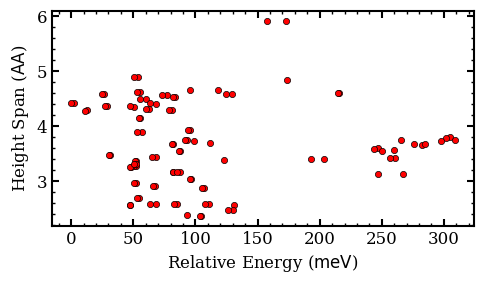

In [42]:
import matplotlib.pyplot as plt

plt.rcParams.update(rcParams)

# Data Conversion
rel_energies_mev = [e * 1000 for e in rel_energies]

# Plotting with Reversed Axes
plt.figure(figsize=(5, 3))
plt.scatter(rel_energies_mev, z_height_spans, color=colors[0], s=20, edgecolors='black', linewidths=0.5)

plt.xlabel(r"Relative Energy ($\text{meV}$)")
plt.ylabel(r"Height Span ($\text{\AA}$)")
plt.tight_layout()
plt.savefig('energy_vs_z_scatter.png', dpi=300)

# PLOT PROBABILITY STATE IN ROOM TEMPERATURE

In [10]:
traj[0].get_potential_energy() - (E_slab + n_fe * mu_fe) 



127.5687608349455

In [16]:
min(relative_eb)

0.0

In [22]:
raw_energies = np.array([atoms.get_potential_energy() for atoms in traj if hasattr(atoms, 'get_potential_energy')])
e_global = np.min(raw_energies)
intensive_energies = (raw_energies - e_global)

intensive_energies

array([8.24028206, 8.14300556, 6.6752979 , 6.58763691, 7.44421311,
       7.16095789, 8.33772046, 8.03281717, 7.62999779, 7.22017555,
       6.6639319 , 5.49160622, 5.20217171, 7.69989452, 7.03757099,
       6.92966285, 7.00869424, 6.76293247, 2.37296464, 2.34672812,
       3.54245752, 2.28975771, 2.22693612, 4.67043157, 4.25433384,
       2.50802715, 1.40432925, 1.36439845, 2.60457268, 2.57688944,
       2.81378692, 2.79312312, 1.8317432 , 1.78089386, 1.50135717,
       1.43417174, 3.3187686 , 1.28141948, 1.27328056, 2.66781821,
       2.21153345, 2.19441587, 3.52478918, 3.39943931, 1.47828315,
       1.44018636, 1.8403905 , 1.72160701, 2.98388364, 2.91404436,
       1.41647464, 1.39375239, 2.20811854, 2.21069297, 1.62471896,
       1.49184273, 2.08814013, 1.97647952, 3.48678937, 3.37115999,
       3.18123355, 2.58167877, 2.58535662, 2.5482933 , 2.52337741,
       2.47229576, 2.19421826, 2.11627692, 0.35075187, 0.30296488,
       4.68933257, 3.02429536, 5.83001983, 5.79291834, 1.69069

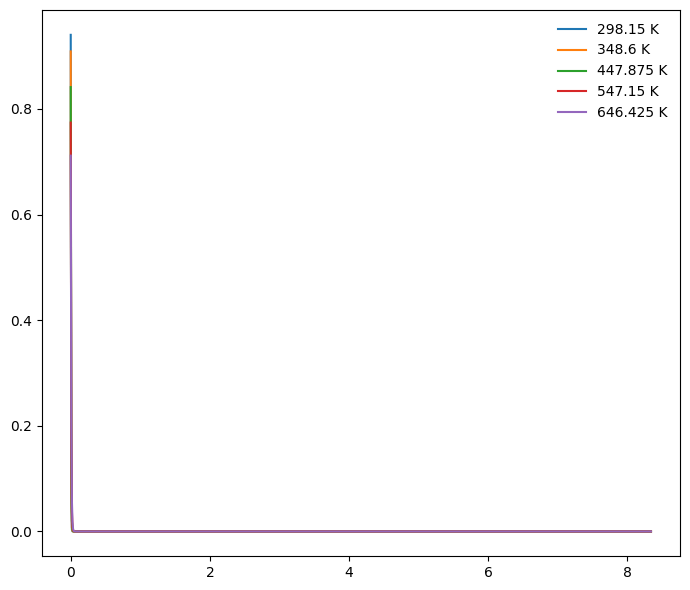

In [37]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()
num_points=1000

# Constants for Binding Energy
# E_slab = -195.463476  # eV
E_slab = -92.946489 # eV
mu_fe = -8.553673     # eV/atom
n_fe = 9              # Number of Fe atoms


# Calculate Binding Energy for each frame: E_b = E_total - (E_slab + n*mu)
binding_energies = np.array([
    # atoms.get_potential_energy() - (E_slab + n_fe * mu_fe) 
    # for atoms in traj if hasattr(atoms, 'get_potential_energy')
    atoms.get_potential_energy()
    for atoms in traj if hasattr(atoms, 'get_potential_energy')
])


# Use relative binding energy for KDE
min_eb = np.min(binding_energies)
relative_eb = binding_energies - min_eb

kde = gaussian_kde(relative_eb)
eb_grid = np.linspace(np.min(relative_eb), np.max(relative_eb), num_points)
eb_density = kde(eb_grid)
eb_density = eb_density/min(eb_density)

########################################

# Statistical Mechanics Loop
kB = 8.617333262e-5
temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
results = []

for T in temperatures:
    beta = 1.0 / (kB * T)
    
    # 1. Intensive Gibbs Level (per atom)
    G_levels = eb_grid - kB * T * np.log(eb_density + 1e-20)
    delta_G_intensive = G_levels - np.min(G_levels)
    
    # 2. Boltzmann weighting using EXTENSIVE energy (total cluster)
    # This is the critical fix:
    boltzmann_factors = np.exp(-beta * (delta_G_intensive * n_fe))
    
    # 3. Partition Function and Probability
    Z = np.sum(boltzmann_factors)
    P_Eb = boltzmann_factors / Z
    
    # 4. Total Ensemble Gibbs Free Energy
    G_total = -kB * T * np.log(Z) + (np.min(G_levels) * n_fe)
    
    results.append({
        'T': T, 
        'G_total': G_total, 
        'P': P_Eb, 
        'G_levels': G_levels
    })

# 3. Plotting with Mandatory Researcher Style
fig, ax = plt.subplots(figsize=(7, 6))

# Tick Parameters as requested
min_x, max_x = -4, 4
min_y, max_y = -2, 4
min_e, max_e = 0.0, 0.8

xticks = np.round(np.linspace(min_x, max_x, 5), 0)
yticks = np.round(np.linspace(min_y, max_y, 5), 1)
eticks = np.round(np.linspace(min_e, max_e, 10), 1)

# xticks_minor = (xticks[:-1] + xticks[1:]) / 2
# yticks_minor = (yticks[:-1] + yticks[1:]) / 2

# ax.set_xlabel('Principal Component 1') # Keeping labels per your style instructions
# ax.set_ylabel('Principal Component 2')
# ax.set_xlim(min_x, max_x)
# ax.set_ylim(min_y, max_y)
# ax.set_xticks(xticks)
# ax.set_yticks(yticks)
# ax.tick_params(labelsize=12)
# ax.xaxis.set_minor_locator(FixedLocator(xticks_minor))
# ax.yaxis.set_minor_locator(FixedLocator(yticks_minor))

# Note: Mapping eb_grid to the required visual range [-4, 4] for PC1 compliance
# Here we plot the Probability P(Eb) across the normalized grid
for res in results:
    # Scale eb_grid for visualization if necessary, or plot directly
    ax.plot(eb_grid, res['P'], label=f"{res['T']} K", lw=1.5)

ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('binding_probability_vs_temperature.png', dpi=300)
plt.show()

## Prev

(Original) Probability State:

$$
p_i = \frac{\exp\left(-\frac{E_i}{k_B T}\right)}{Z}
$$

Boltzmann Factor of every accessable state:
$$
Z = \sum_{j} \exp\left(-\frac{E_j}{k_B T}\right)
$$

### **1. Kernel Density Estimation (KDE)**

We estimate the numerical **Density of States**, $g(E)$, by placing a Gaussian kernel over each observed energy point from your data:

$$g(E) = \frac{1}{Nh} \sum_{i=1}^{N} K \left( \frac{E - E_i}{h} \right)$$

Where:
- $N$ is the number of configurations.
- $h$ is the smoothing bandwidth.
- $K$ is the kernel function (Gaussian).
    

### **2. The Unnormalized Probability**

The probability of occupancy at a specific energy $E$ is the product of the available density of states and the **Boltzmann factor**:

$$P_{unnorm}(E) = g(E) \cdot \exp\left( -\frac{E}{k_B T} \right)$$

### **3. Sum-Normalization**

To treat the energy grid as a discrete set of states where the total probability equals 1, we normalize the distribution by the sum of all points $j$ on the grid:

$$P(E_j) = \frac{g(E_j) e^{-E_j / k_B T}}{\sum_{i=1}^{N} g(E_i) e^{-E_i / k_B T}}$$


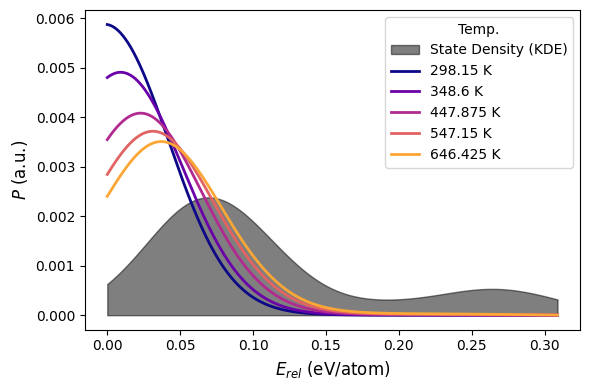

In [9]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

min_energy = np.min(energies)
relative_energies = energies - min_energy

# Constants
k_B = 1.380649e-23  # J/K
ev_to_j = 1.60218e-19

temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
# temperatures = np.linspace(298.15, 1046.425, 100)

def calculate_weighted_probability(relative_energies, temp, num_points=1000, plot_ratio=False):
    # 1. Fit the Energy Density (KDE)
    # This represents the density of states (how often an energy level appears)
    kde = gaussian_kde(relative_energies)
    
    # Create an energy grid for evaluation
    energy_grid = np.linspace(np.min(relative_energies), np.max(relative_energies), num_points)
    energy_density = kde(energy_grid)

    if plot_ratio:
        j = 0.04715
        k = 0
        idx_j = np.abs(energy_grid - j).argmin()
        idx_k = np.abs(energy_grid - k).argmin()

        Ej = energy_grid[idx_j]
        Ek = energy_grid[idx_k]

        g_Ej = energy_density[idx_j]
        g_Ek = energy_density[idx_k]

        energy_diff = Ej - Ek
        boltzmann_ratio = np.exp(-(energy_diff * ev_to_j) / (k_B * temp))
        ratio = (g_Ej / g_Ek) * boltzmann_ratio
        return energy_grid, energy_density, ratio

    
    # 2. Calculate Boltzmann Factors for the grid
    # We use the grid points to ensure the density and factors align
    boltzmann_factors = np.exp(-(energy_grid * ev_to_j) / (k_B * temp))
    
    # 3. Combine: Probability = Density of States * Boltzmann Occupancy
    # Unnormalized combined probability
    combined_prob_unnorm = energy_density * boltzmann_factors
    
    # 4. Normalize so the integral/sum equals 1
    # total_probability = np.trapz(combined_prob_unnorm, energy_grid)
    # final_probability_density = combined_prob_unnorm / total_probability

    final_probability_density = combined_prob_unnorm / np.sum(combined_prob_unnorm)
    energy_density = energy_density / np.sum(energy_density)

    avg_energy = np.sum(energy_grid * final_probability_density)

    
    # if plot_ratio:
    #     idx_ref = 0 
    #     E_k = energy_grid[idx_ref]
    #     g_Ek = energy_density[idx_ref]
        
        # ratio_all = []
        # for T in temp:
        #     # Calculate P(Ej) / P(Ek)
        #     # Ratio = (g_j / g_k) * exp(-(Ej - Ek) / kT)
        #     energy_diff = grid - E_k
        #     boltzmann_ratio = np.exp(-(energy_diff * ev_to_j) / (k_B * T))
        #     ratio = (energy_density / g_Ek) * boltzmann_ratio
        #     ratio_all.append(ratio)
            
    return energy_grid, final_probability_density, energy_density, avg_energy


plt.figure(figsize=(6, 4))

# ratio_all = []
# for i, temp in enumerate(temperatures):
#     # Use ratios
#     grid, prob_dist, ratio = calculate_weighted_probability(relative_energies, temp, plot_ratio=True)
#     ratio_all.append(ratio)

# plt.plot(temperatures,ratio_all)
# plt.show()

# We only need to plot the Raw Density once as a background
grid, _, raw_density_norm, _ = calculate_weighted_probability(relative_energies, temperatures[0])
plt.fill_between(grid, raw_density_norm, alpha=0.5, color='black', label='State Density (KDE)')

# Use a colormap to distinguish temperatures
colors = plt.cm.plasma(np.linspace(0, 0.8, len(temperatures)))

ratio_all = []
for i, temp in enumerate(temperatures):
    grid, prob_dist, _, avg_E = calculate_weighted_probability(relative_energies, temp)
    
    # Plot probability curve
    line, = plt.plot(grid, prob_dist, label=f'{temp} K', color=colors[i], linewidth=2)

    # Plot vertical line for <E> with same color
    # plt.axvline(avg_E, color=colors[i], linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Annotate the average energy for clarity
    # plt.text(avg_E, np.max(prob_dist)*1.02, f'{avg_E:.3f}', 
    #          color=colors[i], horizontalalignment='center', fontsize=9)



plt.xlabel(r'$E_{rel}$ (eV/atom)', fontsize=12)
plt.ylabel('$P$ (a.u.)', fontsize=12)
# plt.title('Evolution of Energy Probability and Ensemble Average with Temperature', fontsize=14)
plt.legend(title="Temp.")
# plt.grid(True, alpha=0.2, linestyle='--')
# plt.ylim(0, 0.08) # Ensure y-axis starts at 0
# plt.xlim(0, 0.30) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()

The Mathematical RatioThe plot will visualize the following relationship as a function of temperature:

$$\frac{P(E_j)}{P(E_k)} = \frac{g(E_j)}{g(E_k)} \exp\left( -\frac{E_j - E_k}{k_B T} \right)$$

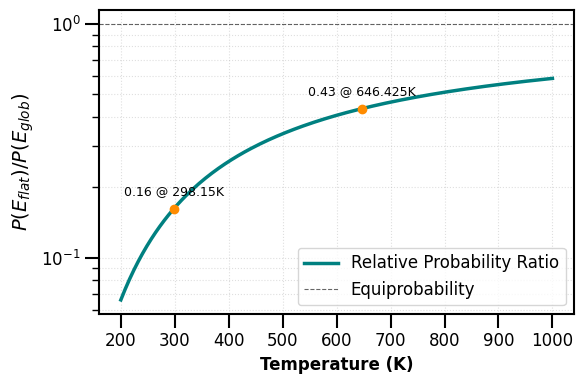

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define a smoother range of temperatures for a clean curve
temp_range = np.linspace(200, 1000, 200) 

ratio_values = []
for t in temp_range:
    # Using your function with the plot_ratio=True flag
    _, _, ratio = calculate_weighted_probability(relative_energies, t, plot_ratio=True)
    ratio_values.append(ratio)

# --- Plot Construction ---
plt.figure(figsize=(6, 4), dpi=100)

# Main ratio curve
plt.plot(temp_range, ratio_values, color='teal', linewidth=2.5, label='Relative Probability Ratio')

# Reference values: specific points from your original list
for t_spec in [298.15, 646.425]:
    _, _, r_spec = calculate_weighted_probability(relative_energies, t_spec, plot_ratio=True)
    plt.scatter(t_spec, r_spec, color='darkorange', zorder=5)
    plt.annotate(f'{r_spec:.2f} @ {t_spec}K', (t_spec, r_spec), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Formatting for Research
plt.yscale('log') # Probability ratios are best viewed on log scales
plt.xlabel('Temperature (K)', fontsize=12, fontweight='bold')
plt.ylabel(r'$P(E_{flat}) / P(E_{glob})$', fontsize=14, fontweight='bold')
# plt.title('Relative State Occupancy vs. Temperature', fontsize=14, pad=15)

# Adding a horizontal line at 1.0 (where states are equally likely)
plt.axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.6, label='Equiprobability')

plt.grid(True, which="both", linestyle=':', alpha=0.4)
plt.legend(frameon=True, loc='lower right')
plt.tight_layout()

plt.show()

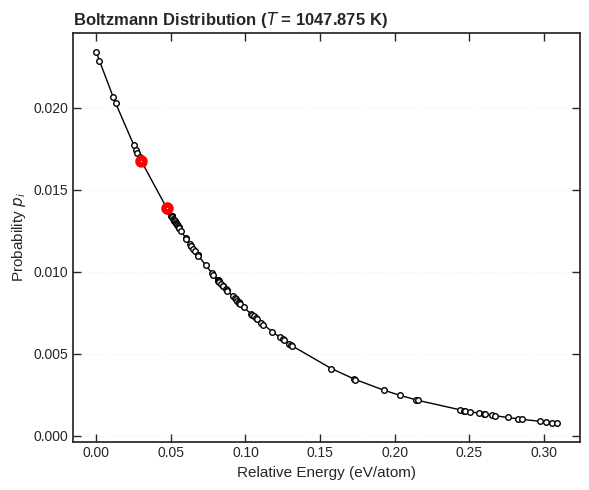

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from agox.databases import Database
import matplotlib.ticker as ticker

# 1. Load Data
dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# 2. Extract Energies (assumed to be in eV from AGOX)
energies = []
for atoms in traj:
    try:
        energies.append(atoms.get_potential_energy()/len(atoms))
    except Exception:
        continue 

energies = np.array(energies)

# 3. Process Energies (Relative to Ground State)
min_idx = np.argmin(energies)
min_energy = energies[min_idx]
relative_energies = energies - min_energy

# 4. Constants & Calculation
# Converting eV to Joules for the standard k_B value
ev_to_j = 1.60218e-19
k_B = 1.380649e-23  
# T = 298.15
T = 447.875
T = 1047.875
# T1 = 298.15
# T2 = 447.875

def calculate_probabilities(E_ev, temp):
    # Convert eV to Joules inside the exponential
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    probabilities = boltzmann_factors / Z
    return probabilities, Z

probs, partition_Z = calculate_probabilities(relative_energies, T)
# probs_t1, partition_Z_t1 = calculate_probabilities(relative_energies, T1)
# probs_t2, partition_Z_t2 = calculate_probabilities(relative_energies, T2)

# 5. Sorting for a smooth Line Graph
# This ensures the line represents the probability distribution from lowest to highest energy
sort_idx = np.argsort(relative_energies)
sorted_relative_energies = relative_energies[sort_idx]
sorted_probs = probs[sort_idx]

# 6. Plotting
import matplotlib.pyplot as plt

# Using a clean style base
plt.style.use('seaborn-v0_8-white') 

fig, ax = plt.subplots(figsize=(6, 5)) # Square-ish ratios look better in papers
ax.plot(sorted_relative_energies, sorted_probs, 
        color='black', 
        marker='o', 
        markersize=4, 
        markerfacecolor='white', 
        markeredgewidth=1,
        linewidth=1, 
        label=f'T = {T} K',
        zorder=1)

ax.scatter(sorted_relative_energies[8], sorted_probs[8], 
           edgecolors='red', 
           facecolors='white', 
           marker='o', 
           s=16,  # s is marker size in points^2; 4^2 = 16
           linewidth=5, 
           label=f'T = {T} K',
           zorder=2)
ax.scatter(sorted_relative_energies[10], sorted_probs[10], 
           edgecolors='red', 
           facecolors='white', 
           marker='o', 
           s=16,  # s is marker size in points^2; 4^2 = 16
           linewidth=5, 
           label=f'T = {T} K',
           zorder=2)

# Minimalist Axis Styling
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel(r'Probability $p_i$', fontsize=11)
# ax.set_yscale('log')

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1, top=True, right=True)
# Minor ticks: Shorter, thinner, pointing IN
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)

# Remove top and right spines (standard minimalist look)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# Refined Grid (Only horizontal for readability, or very subtle)
ax.grid(axis='y', which='both', linestyle=':', alpha=0.3)
# ax.grid(True, which="major", axis="y", ls="-", alpha=0.2, color='gray')

# Title and Layout
ax.set_title(f'Boltzmann Distribution ($T$ = {T} K)', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()

# Save with high DPI for publications
# plt.savefig('boltzmann_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

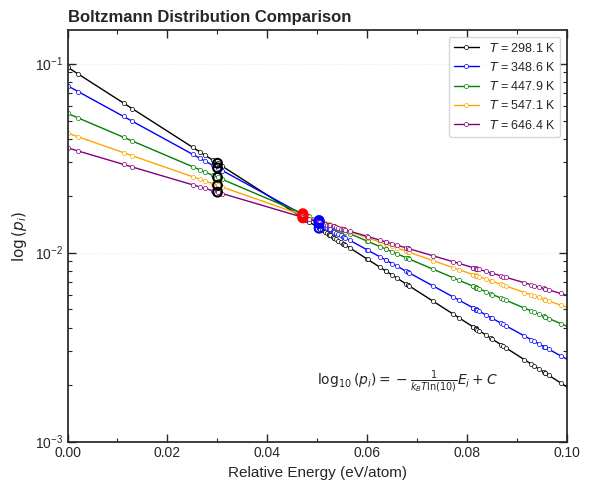

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from agox.databases import Database

# 1. Load Data
dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# 2. Extract Energies per atom
energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

# 3. Process Energies (Relative to Ground State)
min_energy = np.min(energies)
relative_energies = energies - min_energy
sort_idx = np.argsort(relative_energies)
sorted_relative_energies = relative_energies[sort_idx]

# 4. Constants & Temperatures
ev_to_j = 1.60218e-19
k_B = 1.380649e-23  

temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
colors = ['black', 'blue', 'green', 'orange', 'purple']


def calculate_probabilities(E_ev, temp):
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    return boltzmann_factors / Z

# 5. Plotting Setup
plt.style.use('seaborn-v0_8-white') 
fig, ax = plt.subplots(figsize=(6, 5))

# Loop through temperatures
for i, T in enumerate(temperatures):
    # Calculate
    probs = calculate_probabilities(relative_energies, T)
    sorted_probs = probs[sort_idx]
    
    # Line + Scatter Plot
    line_label = f'$T$ = {T:.1f} K'
    ax.plot(sorted_relative_energies, sorted_probs, 
            color=colors[i], 
            marker='o', markersize=3, markerfacecolor='white',
            markeredgewidth=0.5, linewidth=1, 
            label=line_label, zorder=1)

    # Highlight specific indices (e.g., 8 and 10) with red scatter
    # We only label the scatter once to avoid legend clutter
    sc_label = "Highlighted States" if i == 0 else ""
    highlight_idx = [8, 10, 16]
    # ax.scatter(sorted_relative_energies[highlight_idx[0]], sorted_probs[highlight_idx[0]], 
    #            edgecolors='blue', facecolors='none', marker='o', 
    #            s=40, linewidth=1.5, zorder=3, label=sc_label)
    # ax.scatter(sorted_relative_energies[highlight_idx[1]], sorted_probs[highlight_idx[1]], 
    #            edgecolors='red', facecolors='none', marker='o', 
    #            s=40, linewidth=1.5, zorder=3, label=sc_label)
    ax.scatter(sorted_relative_energies[highlight_idx[0]], sorted_probs[highlight_idx[0]], 
               edgecolors='black', facecolors='none', marker='o', 
               s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[1]], sorted_probs[highlight_idx[1]], 
               edgecolors='red', facecolors='none', marker='o', 
               s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[2]], sorted_probs[highlight_idx[2]], 
               edgecolors='blue', facecolors='none', marker='o', 
               s=40, linewidth=1.5, zorder=3)

# 6. Minimalist Research Styling
ax.set_yscale('log')
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel(r'$\log{(p_i)}$', fontsize=11)

# Tickers (Major and Minor)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)

# Grid and Legend
ax.grid(axis='y', which='major', linestyle=':', alpha=0.4)
ax.legend(frameon=True, fontsize=9, loc='upper right')

ax.set_xlim(0.0, 0.1)
ax.set_ylim(0.001, 0.15)

# Mathematical Note Annotation
ax.text(0.05, 0.002, r'$\log_{10}(p_i) = -\frac{1}{k_B T \ln(10)} E_i + C$', 
        fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Title and Final Touches
ax.set_title('Boltzmann Distribution Comparison', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The Mathematical DerivationThe Boltzmann equation is:

$$
p_i = \frac{1}{Z} \exp\left(-\frac{E_i}{k_B T}\right)
$$

Taking the natural logarithm ($\ln$):

$$
\ln(p_i) = \underbrace{-\frac{1}{k_B T}}_{\text{gradient } m} E_i \underbrace{- \ln(Z)}_{\text{intercept } c}
$$

If you use $\log_{10}$ (as in your plot):

$$
\log_{10}(p_i) = \underbrace{-\frac{1}{k_B T \ln(10)}}_{m} E_i \underbrace{- \log_{10}(Z)}_{c}
$$

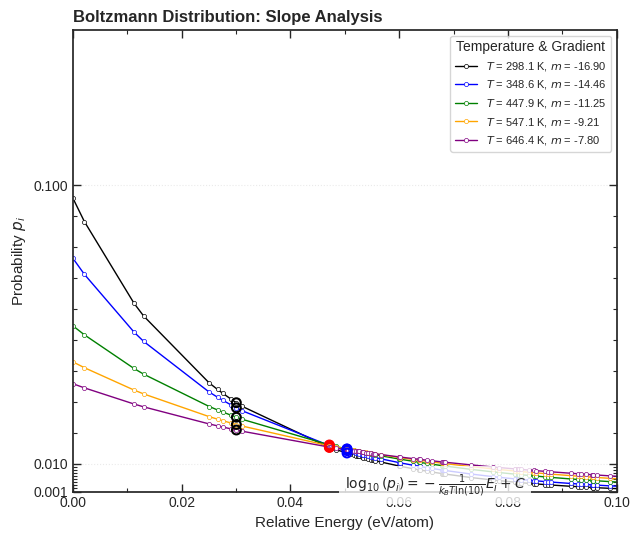

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from agox.databases import Database

# 1. Load Data
dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# 2. Extract Energies per atom
energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

# 3. Process Energies (Relative to Ground State)
min_energy = np.min(energies)
relative_energies = energies - min_energy
sort_idx = np.argsort(relative_energies)
sorted_relative_energies = relative_energies[sort_idx]

# 4. Constants & Temperatures
ev_to_j = 1.60218e-19
k_B = 1.380649e-23  

temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
colors = ['black', 'blue', 'green', 'orange', 'purple']

def calculate_probabilities(E_ev, temp):
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    return boltzmann_factors / Z

# 5. Plotting Setup
plt.style.use('seaborn-v0_8-white') 
fig, ax = plt.subplots(figsize=(6.5, 5.5))

# Loop through temperatures
for i, T in enumerate(temperatures):
    # Calculate
    probs = calculate_probabilities(relative_energies, T)
    sorted_probs = probs[sort_idx]
    
    # CALCULATE GRADIENT (m)
    # We fit log10(p) = m * E + c
    log_p = np.log10(sorted_probs)
    m, c = np.polyfit(sorted_relative_energies, log_p, 1)
    
    # Line + Scatter Plot - Label now includes gradient m
    line_label = f'$T$ = {T:.1f} K, $m$ = {m:.2f}'
    ax.plot(sorted_relative_energies, sorted_probs, 
            color=colors[i], 
            marker='o', markersize=3, markerfacecolor='white',
            markeredgewidth=0.5, linewidth=1, 
            label=line_label, zorder=1)

    # Highlight specific indices
    highlight_idx = [8, 10, 16]
    ax.scatter(sorted_relative_energies[highlight_idx[0]], sorted_probs[highlight_idx[0]], 
               edgecolors='black', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[1]], sorted_probs[highlight_idx[1]], 
               edgecolors='red', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[2]], sorted_probs[highlight_idx[2]], 
               edgecolors='blue', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)

# 6. Minimalist Research Styling
# ax.set_yscale('log')
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel(r'Probability $p_i$', fontsize=11)

# Tickers
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)

# Grid and Legend
ax.grid(axis='y', which='major', linestyle=':', alpha=0.4)
ax.legend(frameon=True, fontsize=8, loc='upper right', title="Temperature & Gradient")

ax.set_xlim(0.0, 0.1)
ax.set_ylim(0.001, 0.15)

# Mathematical Note Annotation
ax.text(0.05, 0.002, r'$\log_{10}(p_i) = -\frac{1}{k_B T \ln(10)} E_i + C$', 
        fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Title
ax.set_title('Boltzmann Distribution: Slope Analysis', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# eV to Kelvin

Conversion FormulaThe Boltzmann constant in units of eV/K is approximately:
$$
k_B \approx 8.6173 \times 10^{-5} \text{ eV/K}
$$

Since $1 \text{ meV} = 10^{-3} \text{ eV}$, the temperature is calculated as:
$$
T = \frac{E_{\text{meV}} \times 10^{-3}}{k_B}
$$

In [20]:
import numpy as np

# Boltzmann constant in eV/K
k_B = 8.617333262e-5

# Input energies in meV
energies_meV = np.array([30.04, 47.15])

# Conversion: meV -> eV -> Kelvin
energies_eV = energies_meV * 1e-3
temperatures_K = energies_eV / k_B

for mev, k in zip(energies_meV, temperatures_K):
    print(f"{mev} meV is equivalent to {k:.2f} K")

30.04 meV is equivalent to 348.60 K
47.15 meV is equivalent to 547.15 K


# Temp Density

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from agox.databases import Database
from scripts.calculate_relative_energy import calculate_relative_energy
from scipy.stats import gaussian_kde


def plot_energy_distribution(
        db_paths,
        labels,
        dir_out,
        dir_im,
        figsize=(4, 6),
        y_label=r'$E_{rel}$ (eV/atom)',
        x_label='State Density',
        colors=None,
        plot_single=False,
        single_index=0,
        linewidth=2.2,
        tick_length=4.0,
        font_size=10,
        font_family='sans-serif',
        x_lim=(None, None, None),
        y_lim=(None, None, None),
        plot_type="box",
        rcParams=None,
        show_legend=True
    ):   
    if rcParams is None:
        rcParams = {
            'font.size': font_size,
            'font.family': font_family,
            'mathtext.fontset': 'cm',
            'xtick.direction': 'in',
            'ytick.direction': 'in',
            'axes.linewidth': linewidth,   
            'xtick.major.width': linewidth,  
            'ytick.major.width': linewidth,  
            'xtick.major.size': tick_length,      
            'ytick.major.size': tick_length,      
        }


    plt.rcParams.update(rcParams)
    plt.figure(figsize=figsize, dpi=300)

    indices = [single_index] if plot_single else range(len(db_paths))

    if plot_type == "density":
        plt.xlabel(x_label)
        plt.ylabel(y_label)
    else:
        plt.ylabel(y_label)

    for idx in indices:
        dir_path, _ = db_paths[idx]
        db_file = os.path.join(dir_path, "1_db", "db_0.db")

        database = Database(filename=db_file)
        trajs = database.restore_to_trajectory()
        _, _, _, rel_energies = calculate_relative_energy(trajs)

        rel_energies = np.array(rel_energies)

        c = colors[idx % len(colors)] if colors else "lightgray"

        if plot_type == "box":
            plt.boxplot(
                rel_energies,
                positions=[idx + 1],
                patch_artist=True,
                boxprops=dict(color='black', facecolor=c, linewidth=linewidth),
                # whiskerprops=dict(color='black', linewidth=linewidth),
                # capprops=dict(color='black', linewidth=linewidth),
                # medianprops=dict(color='black', linewidth=linewidth),
            )
        else:
            ys = np.sort(rel_energies)
            kde = gaussian_kde(ys)

            density_y = np.linspace(ys.min(), ys.max(), 300)
            density_x = kde(density_y)

            plt.plot(density_x, density_y, color=c, linewidth=linewidth)
            plt.fill_betweenx(density_y, 0, density_x, color=c, alpha=0.1)


    if plot_type == "box":
        plt.xticks(
            ticks=[i + 1 for i in indices],
            labels=[labels[i] for i in indices],
            rotation=45
        )

    if x_lim[0] is not None and x_lim[1] is not None:
        xmin_plot, xmax_plot, xstp_plot = x_lim
        plt.xlim(xmin_plot, xmax_plot)
        plt.xticks(np.arange(xmin_plot, xmax_plot, xstp_plot), fontsize=font_size)
    
    else:
        plt.xlim(x_lim[0:2])
    
    if y_lim[0] is not None and y_lim[1] is not None:
        ymin_plot, ymax_plot, ystp_plot = y_lim
        plt.ylim(ymin_plot, ymax_plot)
        plt.yticks(np.arange(ymin_plot, ymax_plot, ystp_plot), fontsize=font_size)
    
    else:
        plt.ylim(y_lim[0:2])    

    if show_legend:
        plt.legend(labels=labels, frameon=True)

    plt.tight_layout()

    fname = "energy_box.png" if plot_type == "box" else "energy_density.png"
    if plot_single:
        fname = "single_" + fname

    out_path = os.path.join(dir_out, dir_im, fname)
    plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


0.9122617307127355


Text(0, 0.5, 'Relative Energy (eV/atom)')

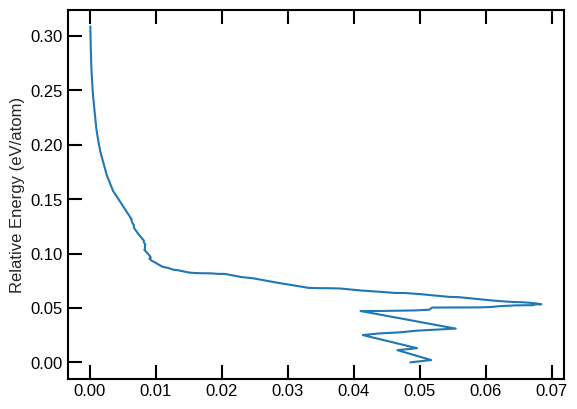

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from agox.databases import Database
from scipy.stats import gaussian_kde


k_B = 1.380649e-23
ev_to_j = 1.60218e-19
T = 500#298.15

dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

min_energy = np.min(energies)
relative_energies = energies - min_energy

sort_idx = np.argsort(relative_energies)
sorted_relative_energies = relative_energies[sort_idx]

def calculate_probabilities(E_ev, temp):
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    return boltzmann_factors / Z

probs = calculate_probabilities(relative_energies, T)
sorted_probs = probs[sort_idx]

# kde = gaussian_kde(relative_energies, weights=probs)

kde = gaussian_kde(sorted_relative_energies, weights=probs)

density_y = np.linspace(sorted_relative_energies.min(), sorted_relative_energies.max(), len(sorted_probs))
density_x = kde(density_y)

print(np.trapz(density_x, density_y))

# Plot Probability
# plt.plot(sorted_probs, sorted_relative_energies)
# plt.boxplot(sorted_relative_energies)
# plt.plot(density_x, density_y)
plt.plot(sorted_probs*density_x, sorted_relative_energies)
# plt.fill_betweenx(density_y, 0, density_x, color=c, alpha=0.1)
plt.ylabel('Relative Energy (eV/atom)')


In [12]:
db_paths

[('0_result/1_1ML_feOnMgo', 0),
 ('0_result/2_1ML_mgoOnFe', 1),
 ('0_result/3_2ML_feOnMgo', 2),
 ('0_result/4_2ML_mgoOnFe', 3)]

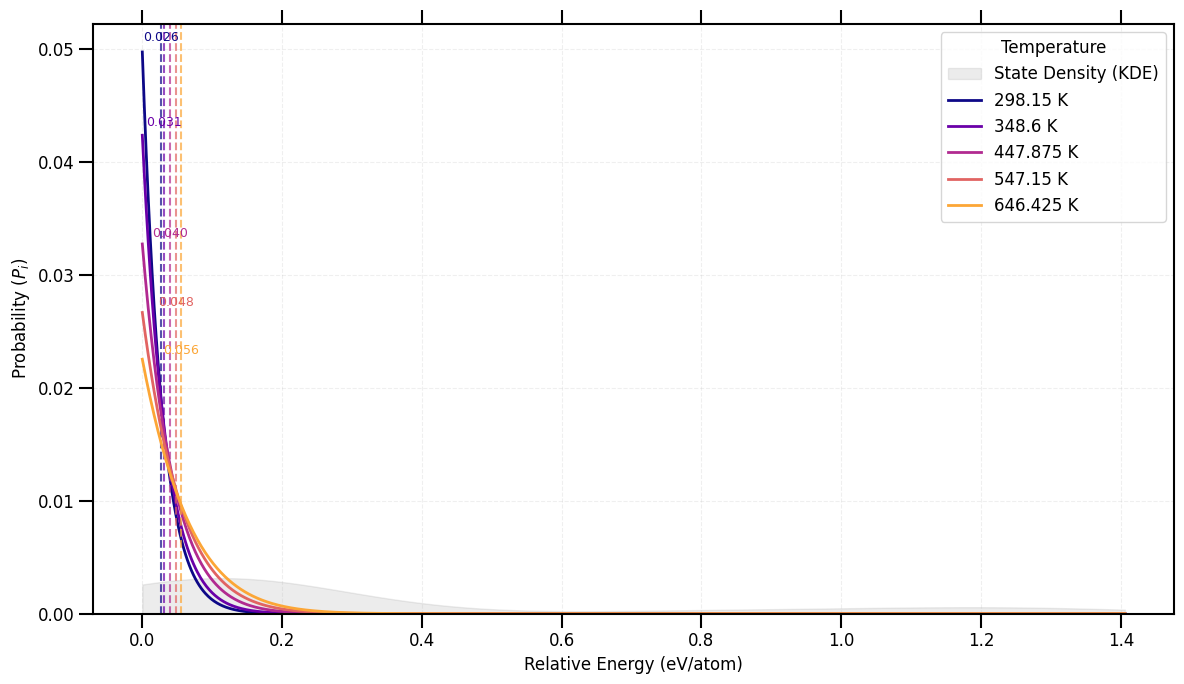

In [15]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

dir_path = db_paths[3][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

min_energy = np.min(energies)
relative_energies = energies - min_energy

# Constants
k_B = 1.380649e-23  # J/K
ev_to_j = 1.60218e-19
temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]

def calculate_weighted_probability(relative_energies, temp, num_points=1000):
    # 1. Fit the Energy Density (KDE)
    # This represents the density of states (how often an energy level appears)
    kde = gaussian_kde(relative_energies)
    
    # Create an energy grid for evaluation
    energy_grid = np.linspace(np.min(relative_energies), np.max(relative_energies), num_points)
    energy_density = kde(energy_grid)
    
    # 2. Calculate Boltzmann Factors for the grid
    # We use the grid points to ensure the density and factors align
    boltzmann_factors = np.exp(-(energy_grid * ev_to_j) / (k_B * temp))
    
    # 3. Combine: Probability = Density of States * Boltzmann Occupancy
    # Unnormalized combined probability
    combined_prob_unnorm = energy_density * boltzmann_factors
    
    # 4. Normalize so the integral/sum equals 1
    # total_probability = np.trapz(combined_prob_unnorm, energy_grid)
    # final_probability_density = combined_prob_unnorm / total_probability

    final_probability_density = combined_prob_unnorm / np.sum(combined_prob_unnorm)
    energy_density = energy_density / np.sum(energy_density)

    avg_energy = np.sum(energy_grid * final_probability_density)
    
    return energy_grid, final_probability_density, energy_density, avg_energy


plt.figure(figsize=(12, 7))

# We only need to plot the Raw Density once as a background
grid, _, raw_density_norm, _ = calculate_weighted_probability(relative_energies, temperatures[0])
plt.fill_between(grid, raw_density_norm, alpha=0.15, color='gray', label='State Density (KDE)')

# Use a colormap to distinguish temperatures
colors = plt.cm.plasma(np.linspace(0, 0.8, len(temperatures)))

for i, temp in enumerate(temperatures):
    grid, prob_dist, _, avg_E = calculate_weighted_probability(relative_energies, temp)
    
    # Plot probability curve
    line, = plt.plot(grid, prob_dist, label=f'{temp} K', color=colors[i], linewidth=2)
    
    # Plot vertical line for <E> with same color
    plt.axvline(avg_E, color=colors[i], linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Annotate the average energy for clarity
    plt.text(avg_E, np.max(prob_dist)*1.02, f'{avg_E:.3f}', 
             color=colors[i], horizontalalignment='center', fontsize=9)

plt.xlabel('Relative Energy (eV/atom)', fontsize=12)
plt.ylabel('Probability ($P_i$)', fontsize=12)
# plt.title('Evolution of Energy Probability and Ensemble Average with Temperature', fontsize=14)
plt.legend(title="Temperature")
plt.grid(True, alpha=0.2, linestyle='--')
plt.ylim(0, None) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()


#####


# Usage
# temp = 550 # Kelvin
# grid, prob_dist, raw_density, avg_E = calculate_weighted_probability(relative_energies, temp)

# import matplotlib.pyplot as plt

# plt.figure(figsize=(9, 5))
# # plt.plot(grid, prob_dist, label=f'Probability Distribution', color='royalblue', linewidth=2)
# # plt.fill_between(grid, raw_density, alpha=0.2, color='royalblue')
# plt.plot(grid, prob_dist, label=f'Probability at {temp}K', color='royalblue', linewidth=2)
# plt.fill_between(grid, raw_density, alpha=0.3, label='Raw Density (KDE)')

# # Add vertical line for average energy
# plt.axvline(avg_E, color='crimson', linestyle='--', linewidth=2, 
#             label=f'Ensemble Average <E> = {avg_E:.4f} eV at {temp}K')

# plt.xlabel('Relative Energy (eV/atom)')
# plt.ylabel('Probability ($P_i$)')
# plt.title(f'Thermalized Distribution at {temp} K')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.fill_between(grid, raw_density, alpha=0.3, label='Raw Density (KDE)')
# plt.plot(grid, prob_dist, label=f'Probability at {temp}K', color='red', linewidth=2)
# plt.xlabel('Relative Energy (eV/atom)')
# plt.ylabel('Probability Density')
# plt.legend()
# plt.show()

In [71]:
sum(prob_dist)

3239.6458294151676

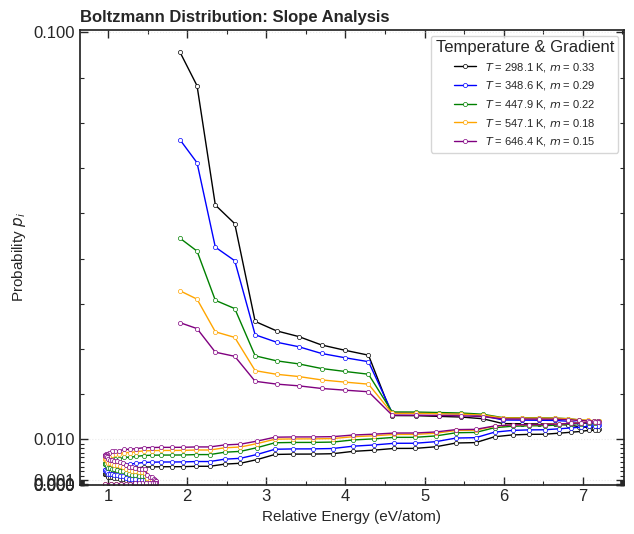

In [ ]:




density_x = np.linspace(sorted_relative_energies.min(), sorted_relative_energies.max(), 108)
# density_y = np.linspace(sorted_relative_energies.min(), sorted_relative_energies.max(), 108)
density_y = kde(density_x)

sorted_relative_energies = density_y

# 4. Constants & Temperatures
ev_to_j = 1.60218e-19
k_B = 1.380649e-23  

temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
colors = ['black', 'blue', 'green', 'orange', 'purple']

def calculate_probabilities(E_ev, temp):
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    return boltzmann_factors / Z

# 5. Plotting Setup
plt.style.use('seaborn-v0_8-white') 
fig, ax = plt.subplots(figsize=(6.5, 5.5))

# Loop through temperatures
for i, T in enumerate(temperatures):
    # Calculate
    probs = calculate_probabilities(relative_energies, T)
    sorted_probs = probs[sort_idx]
    
    # CALCULATE GRADIENT (m)
    # We fit log10(p) = m * E + c
    log_p = np.log10(sorted_probs)
    m, c = np.polyfit(sorted_relative_energies, log_p, 1)
    
    # Line + Scatter Plot - Label now includes gradient m
    line_label = f'$T$ = {T:.1f} K, $m$ = {m:.2f}'
    ax.plot(sorted_relative_energies, sorted_probs, 
            color=colors[i], 
            marker='o', markersize=3, markerfacecolor='white',
            markeredgewidth=0.5, linewidth=1, 
            label=line_label, zorder=1)

    # Highlight specific indices
    # highlight_idx = [8, 10, 16]
    # ax.scatter(sorted_relative_energies[highlight_idx[0]], sorted_probs[highlight_idx[0]], 
    #            edgecolors='black', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)
    # ax.scatter(sorted_relative_energies[highlight_idx[1]], sorted_probs[highlight_idx[1]], 
    #            edgecolors='red', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)
    # ax.scatter(sorted_relative_energies[highlight_idx[2]], sorted_probs[highlight_idx[2]], 
    #            edgecolors='blue', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)

# 6. Minimalist Research Styling
# ax.set_yscale('log')
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel(r'Probability $p_i$', fontsize=11)

# Tickers
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)

# Grid and Legend
ax.grid(axis='y', which='major', linestyle=':', alpha=0.4)
ax.legend(frameon=True, fontsize=8, loc='upper right', title="Temperature & Gradient")

# ax.set_xlim(0.0, 0.1)
# ax.set_ylim(0.001, 0.15)

# Mathematical Note Annotation
# ax.text(0.05, 0.002, r'$\log_{10}(p_i) = -\frac{1}{k_B T \ln(10)} E_i + C$', 
#         fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Title
ax.set_title('Boltzmann Distribution: Slope Analysis', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Write Ta-B Amorphous

$$
c_B = \frac{N_B}{N_{Ta} + N_B}
$$

Solve for (N_B):

$$
N_B = \frac{c_B}{1 - c_B}, N_{Ta}
$$


In [ ]:
import os
import numpy as np

from ase import Atoms
from ase.build import bulk
from ase.io import write

from agox import AGOX
from agox.environments import Environment
from agox.generators import RattleGenerator
from agox.samplers import KMeansSampler, FixedSampler
from agox.collectors import ParallelCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.postprocessors import ParallelRelaxPostprocess
from agox.evaluators import LocalOptimizationEvaluator
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.helpers import SubprocessGPAW

# from scripts.amorph_struct_randomize import AmorphStructRandomize
from scripts.add_B_concentration import add_B_concentration

a_ta = 3.30

"""
Cell volume controls
"""
scale_cell = 1.00 # 1.05->+5%

supercell = (3, 3, 3)
kpts = (4, 4, 4) 
ncores = 16 # 16 genkai
cB = 0.01 # B concentrations (%)
N_iterations = 100 # AGOX iterations

path_result = "0_simul"
path_xsf = f"{path_result}/0_xsf"
path_fig = f"{path_result}/1_fig"
db_dir = f"{path_result}/1_db"

for p in [path_result, path_xsf, path_fig, db_dir]:
	os.makedirs(p, exist_ok=True)

ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell
ta_bulk.set_cell(ta_bulk.cell * scale_cell, scale_atoms=True)

tab_bulk, n_b, n_ta = add_B_concentration(
	ta_bulk, cB=cB, make_structure=True
)

"""
Environment is an empty cells. Size of ta_bulk. 
"""
template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)
environment = Environment(
	template=template,
	symbols=tab_bulk.get_chemical_formula(),
	confinement_cell=template.cell.copy(),
	confinement_corner=np.array([0, 0, 0]),
	box_constraint_pbc=[True, True, True],
)

n_rattle = len(ta_bulk)
generators = [
	AmorphStructRandomize(
		**environment.get_confinement(),
		amorph=tab_bulk,
		write_struct=True,
		rattle_amplitude=1.5,
		n_rattle=n_rattle,
		generate_pristine=False,
	
	),
	AmorphPermutationGenerator(
		**environment.get_confinement(),
		max_number_of_swaps=1,
		rattle_strength=0.0,
	),
	RattleGenerator(
		**environment.get_confinement(),
		n_rattle=int(0.7 * n_rattle),
		rattle_amplitude=2.3,
	),
]

for i in range(100):
	amorph_candidate = generators[0](sampler=None, environment=environment)[0]
	write(f"{path_xsf}/amorph_candidate_{i}.xsf", amorph_candidate)
	print(f"amorph {i}")
	
	sampler = FixedSampler(amorph_candidate)
	write(f"{path_xsf}/permut_candidate_{i}.xsf", generators[1](sampler, environment)[0])
	print(f"permut {i}")
	
	write(f"{path_xsf}/rattle_candidate_{i}.xsf", generators[2](sampler, environment)[0])
	print(f"rattle {i}")


In [3]:
"""
AGOX workflow for amorphous Ta–B bulk optimization
- Builds a periodic Ta supercell with dilute B
- Generates amorphous/permuted/rattled candidates
- Runs Bayesian optimization with GPAW relaxations
"""

import os
import numpy as np
from ase import Atoms
from ase.build import bulk
from ase.io import write

from agox import AGOX
from agox.environments import Environment
from agox.generators import RattleGenerator, PermutationGenerator
from agox.generators import RattleGenerator
from agox.samplers import KMeansSampler, FixedSampler
from agox.collectors import ParallelCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.postprocessors import ParallelRelaxPostprocess
from agox.evaluators import LocalOptimizationEvaluator
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.helpers import SubprocessGPAW

# from scripts.amorph_struct_randomize import AmorphStructRandomize
from scripts.add_B_concentration import add_B_concentration

# === Global parameters ===
a_ta = 3.30                    # Ta bcc lattice constant (Å)
scale_cell = 1.00              # 1.05->+5%,
supercell = (3, 3, 3)          # Periodic replication
kpts = (4, 4, 4)               # GPAW k-point mesh
ncores = 16                    # GPAW MPI cores; 16 cores for genkai
cB = 0.01                       # Boron consentration
N_iterations = 100             # AGOX optimization steps

# === Output paths ===
path_result = "0_simul"
path_xsf = f"{path_result}/0_xsf"
path_fig = f"{path_result}/1_fig"
db_dir = f"{path_result}/1_db"

for p in [path_result, path_xsf, path_fig, db_dir]:
    os.makedirs(p, exist_ok=True)

# === Build Ta bulk and empty template ===
#ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell
#template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)
ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell
ta_bulk.set_cell(ta_bulk.cell * scale_cell, scale_atoms=True)
template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)

# === Add dilute B concentration to Ta bulk ===
#tab_bulk, n_b, n_ta = add_B_concentration(
#    ta_bulk, cB=0.1, make_structure=True
#)
tab_bulk, n_b, n_ta = add_B_concentration(
    ta_bulk, cB=cB, make_structure=True
)

# === Define AGOX environment (periodic confinement) ===
environment = Environment(
    template=template,
    symbols=tab_bulk.get_chemical_formula(),
    confinement_cell=template.cell.copy(),
    confinement_corner=np.array([0, 0, 0]),
    box_constraint_pbc=[True, True, True],
)

# === Structure generators ===
n_rattle = len(ta_bulk)

generators = [
    # Randomize into amorphous configuration
    AmorphStructRandomize(
        **environment.get_confinement(),
        amorph=tab_bulk,
        write_struct=True,
        rattle_amplitude=1.5,
        n_rattle=n_rattle,
        generate_pristine=False,
        big_atom = 73,
    ),
    # Swap chemical species positions
    PermutationGenerator(
        **environment.get_confinement(),
        max_number_of_swaps=1,
        rattle_strength=0.0,
    ),
    # Random atomic displacements
    RattleGenerator(
        **environment.get_confinement(),
        n_rattle=int(0.7 * n_rattle),
        rattle_amplitude=2.3,
    ),
]

# # === Generator sanity checks ===
# amorph_candidate = generators[0](sampler=None, environment=environment)[0]
# write(f"{path_xsf}/amorph_candidate.xsf", amorph_candidate)

# sampler = FixedSampler(amorph_candidate)
# write(f"{path_xsf}/permut_candidate.xsf", generators[1](sampler, environment)[0])
# write(f"{path_xsf}/rattle_candidate.xsf", generators[2](sampler, environment)[0])

for i in range(1000):
    amorph_candidate = generators[0](sampler=None, environment=environment)[0]
    write(f"{path_xsf}/amorph_candidate_{i}.xsf", amorph_candidate)
    print(f"amorph {i}")

    sampler = FixedSampler(amorph_candidate)
    write(f"{path_xsf}/permut_candidate_{i}.xsf", generators[1](sampler, environment)[0])
    print(f"permut {i}")
    write(f"{path_xsf}/rattle_candidate_{i}.xsf", generators[2](sampler, environment)[0])
    print(f"rattle {i}")

# === Database ===
database = Database(filename=f"{db_dir}/db_0.db", order=5)

# === Descriptor and GPR model ===
descriptor = Fingerprint(environment=environment)

beta = 0.01
k0 = C(beta, (beta, beta)) * RBF()
k1 = C(1 - beta, (1 - beta, 1 - beta)) * RBF()
kernel = C(5000, (1, 1e5)) * (k0 + k1) + Noise(0.01, (0.01, 0.01))

model = GPR(
    descriptor=descriptor,
    kernel=kernel,
    database=database,
    prior=Repulsive(),
)

# === Sampling and candidate collection ===
sampler = KMeansSampler(
    descriptor=descriptor,
    database=database,
    sample_size=20,
)

num_candidates = {0: [20, 0, 0], 10: [10, 10, 0], 25: [0, 10, 10]}

collector = ParallelCollector(
    generators=generators,
    sampler=sampler,
    environment=environment,
    num_candidates=num_candidates,
    order=1,
)

# === Acquisition and local relaxation ===
acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=2, order=3)

relaxer = ParallelRelaxPostprocess(
    model=acquisitor.get_acquisition_calculator(),
    constraints=environment.get_constraints(),
    optimizer_run_kwargs={"steps": 100},
    start_relax=10,
    order=2,
)

# === GPAW calculator ===
calc = SubprocessGPAW(
    ncores=ncores,
    mode={"name": "lcao"},
    basis="dzp",
    xc="PBE",
    kpts=kpts,
    symmetry="off",
    nbands="nao",
    #spinpol=True,
    #hund=True,
    mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
    convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
    occupations={"name": "fermi-dirac", "width": 0.05},
    maxiter=100,
    txt="output.txt",
)

# === Energy/force evaluation ===
evaluator = LocalOptimizationEvaluator(
    calc,
    gets={"get_key": "prioritized_candidates"},
    optimizer_kwargs={"logfile": None},
    optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
    constraints=environment.get_constraints(),
    order=4,
)

# === Run AGOX optimization ===
agox = AGOX(
    collector,
    relaxer,
    acquisitor,
    evaluator,
    database,
    seed=1,
)

agox.run(N_iterations=N_iterations)



╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     B = 1                                                                    │
│     Ta = 54                                                                  │
│ Template formula:                                                            │
│ Full formula: BTa54                                                          │
│ Cell:                                                                        │
│     9.90 0.00 0.00                                                           │
│     0.00 9.90 0.00                                                           │
│     0.00 0.00 9.90                                                           │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     9.90 0.00 0.00                                                           │
│     0.00 9.90 0.00                                                           │
│     0.00 0.00 9.90                                                           │
╰──────────────────────────────────────────────────────────────────────────────╯

[AmorphStructRandomize] Saving structures to: generated_structures/run_20260331_080027
amorph 0
permut 0
rattle 0
amorph 1


No swaps possible

IndexError: list index out of range

In [2]:
from agox.generators.ABC_generator import GeneratorBaseClass
from agox.candidates import Candidate
from ase import Atoms

from pathlib import Path
from datetime import datetime

import numpy as np
from ase.io import write


class AmorphStructRandomize(GeneratorBaseClass):
    """
    Generator that randomly rattles selected atoms in a structure.
    """

    name = "AmorphStructRandomize"
    __version__ = "0.0.1"

    def __init__(self,
                 amorph: Atoms,
                 write_struct: bool = False,      # Save generated structures to disk
                 attempts: int = 100,             # Max attempts per atom to find valid displacement
                 replace: bool = True,
                 rattle_amplitude: float = 3.0,   # Maximum displacement magnitude (Å)
                 n_rattle: int = 3,                # Unused here, reserved for future logic
                 generate_pristine: bool = False, # Skip rattling if True
                 output_dir: str = "generated_structures",
                 **kwargs):

        super().__init__(replace=replace, **kwargs)

        self.amorph = amorph

        self.attempts = attempts
        self.write_struct = write_struct
        self.rattle_amplitude = rattle_amplitude
        self.n_rattle = n_rattle
        self.generate_pristine = generate_pristine

        self.output_dir = Path(output_dir)
        self.structure_counter = 0
        self.run_dir = self._create_new_run_dir() if write_struct else None

    def _get_candidates(self, candidate, parents, environment):
        """
        Apply random displacements ("rattling") to atoms in the candidate.
        """

        candidate.extend(Atoms(numbers=self.amorph.numbers,
                               positions=self.amorph.get_positions()))

        # Skip modification if pristine structure is requested
        if not self.generate_pristine:

            # Determine which atoms should be rattled
            indices_to_rattle = self.get_indices_to_rattle(candidate)

            # Rattle atoms sequentially (order matters if layered)
            for i in indices_to_rattle:
                for _ in range(self.attempts):

                    # Random radius with uniform sampling in volume
                    radius = (
                        self.rattle_amplitude
                        * np.random.rand() ** (1 / self.get_dimensionality())
                    )

                    # Random displacement vector
                    displacement = self.get_displacement_vector(radius)
                    new_pos = candidate.positions[i] + displacement

                    # Enforce confinement (e.g. slab or box limits)
                    if not self.check_confinement(new_pos).all():
                        continue

                    # Enforce distance constraints to other atoms
                    if self.check_new_position(
                        candidate,
                        new_pos,
                        candidate[i].number,
                        skipped_indices=[i],
                    ):
                        candidate[i].position = new_pos
                        break

        # Optionally write the generated structure to file
        if self.write_struct:
            self.structure_counter += 1
            filename = self.run_dir / f"amorph_rand_{self.structure_counter:04d}.xsf"
            write(filename, candidate)

        return [candidate]

    def _create_new_run_dir(self):
        """Create a unique directory for storing generated structures."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        run_dir = self.output_dir / f"run_{timestamp}"
        run_dir.mkdir(parents=True, exist_ok=True)
        self.structure_counter = 0
        print(f"[AmorphStructRandomize] Saving structures to: {run_dir}")
        return run_dir

    def get_indices_to_rattle(self, candidate: Candidate) -> np.ndarray:
        """
        Return atom indices to be rattled.
        Currently selects all template atoms.
        """
        # template = candidate.get_template()
        return np.arange(len(self.amorph))

    def get_number_of_parents(self, sampler):
        """This generator does not use parent candidates."""
        return 0

In [20]:
import numpy as np
from ase.data import covalent_radii
from ase.io import write

from agox.generators.ABC_generator import GeneratorBaseClass
from agox.candidates import Candidate

class ModifiedPermutationGenerator(GeneratorBaseClass):
    """
    Permutes atoms of different species in a seed structure.

    TODO: Clean-up this code. Its bad.

    Parameters
    -----------
    max_number_of_swaps : int
        Maximum number of permutations to perform.
    rattle_strength : float
        Maximum distance to permute atoms.
    use_xy_only : bool
        If True, only permute in xy-plane.
    ignore_H : bool
        If True, ignore hydrogen atoms.
    write_candidates_to_disk : bool
        If True, write candidates to disk.

    """

    name = "ModifiedPermutationGenerator"

    def __init__(
        self,
        max_number_of_swaps=1,
        rattle_strength=0.0,
        use_xy_only=False,
        ignore_H=False,
        write_candidates_to_disk=False,

        rattle_amplitude: int = 3,
        n_rattle: int = 3,
        attempts=100,
        
        replace=True,
        **kwargs,
    ):
        super().__init__(replace=replace, **kwargs)
        self.max_number_of_swaps = max_number_of_swaps
        self.rattle_strength = rattle_strength
        self.ignore_H = ignore_H
        self.use_xy_only = use_xy_only
        self.write_candidates_to_disk = write_candidates_to_disk

        self.n_rattle = n_rattle
        self.attempts = attempts
        self.rattle_amplitude = rattle_amplitude

    def _get_candidates(self, candidate, parents, environment):
        if self.write_candidates_to_disk:
            write(f"candidate_{self.counter}.traj", candidate)

        template = candidate.get_template()

        number_of_atoms = len(candidate)
        number_of_template_atoms = len(candidate.get_template())
        number_of_non_template_atoms = number_of_atoms - number_of_template_atoms

        symbols = candidate.get_atomic_numbers()[number_of_template_atoms:]
        unique_symbols = np.unique(symbols)

        if self.ignore_H:
            unique_symbols = np.array([s for s in unique_symbols if s != 1])

        number_of_unique_symbols = len(unique_symbols)
        assert number_of_unique_symbols > 1, "Cannot be used for single component systems"

        number_of_swaps = np.random.randint(self.max_number_of_swaps) + 1

        for n in range(number_of_swaps):
            symbol_i = unique_symbols[np.random.randint(number_of_unique_symbols)]
            remaining_symbols = np.delete(
                unique_symbols, [idx for idx in range(number_of_unique_symbols) if unique_symbols[idx] == symbol_i]
            )

            symbol_j = remaining_symbols[np.random.randint(number_of_unique_symbols - 1)]

            idx_symbol_i = np.argwhere(symbols == symbol_i).reshape(-1) + number_of_template_atoms
            idx_symbol_j = np.argwhere(symbols == symbol_j).reshape(-1) + number_of_template_atoms

            combinations_ij = np.array(np.meshgrid(idx_symbol_i, idx_symbol_j)).T.reshape(-1, 2)

            for row in np.random.permutation(combinations_ij):
                swap_idx_i = row[0]
                swap_idx_j = row[1]

                new_positions = candidate.get_positions()
                new_positions[[swap_idx_i, swap_idx_j]] = new_positions[[swap_idx_j, swap_idx_i]]
                if self.use_xy_only:
                    new_positions[swap_idx_i] += self.pos_add_disk(self.rattle_strength)
                    new_positions[swap_idx_j] += self.pos_add_disk(self.rattle_strength)
                else:
                    new_positions[swap_idx_i] += self.pos_add_sphere(self.rattle_strength)
                    new_positions[swap_idx_j] += self.pos_add_sphere(self.rattle_strength)
                
                
                candidate.set_positions(new_positions)

                #####################
                # indices_to_rattle = self.get_indices_to_rattle(candidate)
                indices_to_rattle = np.arange(len(candidate))

                print(indices_to_rattle)

                for i in indices_to_rattle:
                    for _ in range(self.attempts):  # For atom i attempt to rattle up to 100 times.
                        radius = self.rattle_amplitude * np.random.rand() ** (1 / self.get_dimensionality())
                        displacement = self.get_displacement_vector(radius)
                        suggested_position = candidate.positions[i] + displacement

                        # Check confinement limits:
                        if not self.check_confinement(suggested_position).all():
                            continue

                        # Check that suggested_position is not too close/far to/from other atoms
                        # Skips the atom it self.
                        if self.check_new_position(
                            candidate,
                            suggested_position,
                            candidate[i].number,
                            skipped_indices=[i],
                        ):
                            candidate[i].position = suggested_position
                            break

                # swap_successfull = True
                # near_enough_to_other_atoms = False
                # for i in (swap_idx_i, swap_idx_j):
                #     for other_atom_idx in range(len(candidate)):
                #         if other_atom_idx in [swap_idx_i, swap_idx_j]:
                #             continue
                #         other_atom = candidate[other_atom_idx]

                #         covalent_dist = covalent_radii[candidate[i].number] + covalent_radii[other_atom.number]

                #         rmin = 0.85 * covalent_dist
                #         rmax = 1.15 * covalent_dist

                #         tmp = np.linalg.norm(other_atom.position - new_positions[i])
                #         if np.linalg.norm(other_atom.position - new_positions[i]) < rmin:
                #             swap_successfull = False
                #             break
                #         if np.linalg.norm(other_atom.position - new_positions[i]) < rmax:
                #             near_enough_to_other_atoms = True
                #     if not swap_successfull or not near_enough_to_other_atoms:
                #         break

                # if not swap_successfull or not near_enough_to_other_atoms:
                #     continue

                # candidate.set_positions(new_positions)
                if self.write_candidates_to_disk:
                    write(f"candidate_swap_{n}_{self.counter}.traj", candidate)
                break
            else:
                self.writer("No swaps possible")
                return []

        return [candidate]

    def pos_add_disk(self, rattle_strength):
        """Help function for rattling within a disk"""
        r = rattle_strength * np.random.rand() ** (1 / 2)
        theta = np.random.uniform(low=0, high=2 * np.pi)
        pos_add = r * np.array([np.cos(theta), np.sin(theta), 0])
        return pos_add

    def pos_add_sphere(self, rattle_strength):
        """Help function for rattling within a sphere"""
        r = rattle_strength * np.random.rand() ** (1 / 3)
        theta = np.random.uniform(low=0, high=2 * np.pi)
        phi = np.random.uniform(low=0, high=np.pi)
        pos_add = r * np.array([np.cos(theta) * np.sin(phi), np.sin(theta) * np.sin(phi), np.cos(phi)])
        return pos_add
    
    def get_indices_to_rattle(self, candidate: Candidate) -> np.ndarray:
        template = candidate.get_template()
        n_template = len(template)
        n_total = len(candidate)
        n_non_template = n_total - n_template
        probability = self.n_rattle / n_non_template
        indices_to_rattle = np.arange(n_template, n_total)[np.random.rand(n_non_template) < probability]
        indices_to_rattle = np.random.permutation(indices_to_rattle)
        if len(indices_to_rattle) == 0:
            indices_to_rattle = [np.random.randint(n_template, n_total)]
        return indices_to_rattle

    def get_number_of_parents(self, sampler):
        return 1


In [24]:
from agox.generators import RattleGenerator, PermutationGenerator

# from scripts.amorph_struct_randomize import AmorphStructRandomize
# from scripts.modified_permut_generator import ModifiedPermutationGenerator
from scripts.generate_volume_variants import generate_volume_variants
from scripts.add_B_concentration import add_B_concentration

from agox.samplers import FixedSampler

import numpy as np
from agox.environments import Environment
from ase.build import surface, bulk
from ase.io import write
from ase import Atoms
from icecream import ic

# === AGoX Environment ===
scale_cell = 1.10              # 1.05->+5%,
cB=0.05
ta_bulk = bulk('Ta', 'bcc', a=3.30, cubic=True) * (3, 3, 3)
ta_bulk.set_cell(ta_bulk.cell * scale_cell, scale_atoms=True)
template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)

# example: fixed position, ~1 at.% B
tab_bulk, n_b, n_ta = add_B_concentration(
    ta_bulk,
    cB=cB,
    make_structure=True
)

atom_num = len(set(tab_bulk.get_atomic_numbers()))
ic(atom_num)

confinement_cell = template.cell.copy()
confinement_corner = np.array([0, 0, 0])

environment = Environment(
    template=template,
    symbols=tab_bulk.get_chemical_formula(),
    confinement_cell=confinement_cell,
    confinement_corner=confinement_corner,
    box_constraint_pbc=[True, True, True],  # Confinement is periodic in all directions.
)

# === Structure Generators ===
n_rattle = len(tab_bulk)

amorph_generator = AmorphStructRandomize(
                  **environment.get_confinement(),
                  amorph = tab_bulk,
                  write_struct=True,
                  rattle_amplitude=3,
                  n_rattle=n_rattle,
                  generate_pristine=False,
                )

rattle_generator = RattleGenerator(
                  **environment.get_confinement(),
                    n_rattle=int(n_rattle * 0.7),
                    rattle_amplitude=3
                )

permut_generator = ModifiedPermutationGenerator(
                    **environment.get_confinement(),
                    max_number_of_swaps=10,
                    rattle_strength=1.0,
                    rattle_amplitude = 3,
                    n_rattle = n_rattle,
                    attempts = 100,
                )

amorph_candidate = amorph_generator(sampler=None, environment=environment)

sampler = FixedSampler(amorph_candidate)

rattle_candidate = rattle_generator(sampler, environment)
permut_candidate = permut_generator(sampler, environment)

print(permut_candidate)

write("amorph.xsf", amorph_candidate)
write("rattle.xsf", rattle_candidate)
write("permut.xsf", permut_candidate)


ic| atom_num: 2


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     B = 3                                                                    │
│     Ta = 54                                                                  │
│ Template formula:                                                            │
│ Full formula: B3Ta54                                                         │
│ Cell:                                                                        │
│     10.89 0.00 0.00                                                          │
│     0.00 10.89 0.00                                                          │
│     0.00 0.00 10.89                                                          │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     10.89 0.00 0.00                                                          │
│     0.00 10.89 0.00                                                          │
│     0.00 0.00 10.89                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯

[AmorphStructRandomize] Saving structures to: generated_structures/run_20260123_211216
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56]
[ 0  1  2  3  4  5  6  7  8  9 10 11 1

## Amorphous Run

In [ ]:
from ase.build import bulk
from gpaw import GPAW, LCAO, FermiDirac

# Calculator: 1820.79 MiB
# 54 atoms
atoms = bulk('Ta', 'bcc', a=3.30, cubic=True)
supercell = atoms * (3, 3, 3)

calc = GPAW(
    mode=LCAO(),                # Use LCAO mode
    basis='dzp',                # Double-Zeta Polarized basis set
    xc='PBE',                   # Exchange-Correlation functional
    h=0.22,                     # Real-space grid spacing (Angstrom)
    kpts={'size': (3, 3, 3), 'gamma': True}, # Denser k-points for LCAO metals
    occupations=FermiDirac(0.1), # Smearing for the metal Fermi surface
    convergence={
        'energy': 1e-6,              # Energy convergence per atom
        'density': 1e-4,             # Density convergence
    },
    symmetry={'point_group': False}, # Off to avoid errors during distortions
    txt='Ta_LCAO_3x3x3.txt'
)

supercell.calc = calc

energy = supercell.get_potential_energy()
print(f"Total Energy: {energy:.4f} eV")

In [ ]:
"""
AGOX workflow for amorphous Ta–B bulk optimization
- Builds a periodic Ta supercell with dilute B
- Generates amorphous/permuted/rattled candidates
- Runs Bayesian optimization with GPAW relaxations
"""

import os
import numpy as np
from ase import Atoms
from ase.build import bulk
from ase.io import write

from agox import AGOX
from agox.environments import Environment
from agox.generators import RattleGenerator, PermutationGenerator
from agox.samplers import KMeansSampler, FixedSampler
from agox.collectors import ParallelCollector, StandardCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.postprocessors import ParallelRelaxPostprocess, RelaxPostprocess
from agox.evaluators import LocalOptimizationEvaluator
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.helpers import SubprocessGPAW

from scripts.amorph_struct_randomize import AmorphStructRandomize
from scripts.add_B_concentration import add_B_concentration

from gpaw import FermiDirac

import ray

# memory = 32000000000.0
# object_store_memory = 8000000000.0
# memory = 34000000000.0
# object_store_memory = 4000000000.0

# ray.init(
#     memory = memory,          
#     object_store_memory = object_store_memory 
# )

# memory = 7000000000.0 
# object_store_memory = 5000000000.0

# ray.init(      
#     object_store_memory = object_store_memory,
# )



# === Global parameters ===
a_ta = 3.30                    # Ta bcc lattice constant (Å)
scale_cell = 1.05              # 1.05->+5%,
supercell = (3, 3, 3)          # Periodic replication
kpts = (3, 3, 3)               # GPAW k-point mesh
ncores = 1                    # GPAW MPI cores; 16 cores for genkai
cB = 0.04                       # Boron consentration
N_iterations = 100             # AGOX optimization steps

# === Output paths ===
path_result = "0_simul"
path_xsf = f"{path_result}/0_xsf"
path_fig = f"{path_result}/1_fig"
db_dir = f"{path_result}/1_db"

for p in [path_result, path_xsf, path_fig, db_dir]:
    os.makedirs(p, exist_ok=True)

# === Build Ta bulk and empty template ===
#ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell
#template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)
ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell
ta_bulk.set_cell(ta_bulk.cell * scale_cell, scale_atoms=True)
template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)

# === Add dilute B concentration to Ta bulk ===
#tab_bulk, n_b, n_ta = add_B_concentration(
#    ta_bulk, cB=0.1, make_structure=True
#)
tab_bulk, n_b, n_ta = add_B_concentration(
    ta_bulk, cB=cB, make_structure=True
)

# === Define AGOX environment (periodic confinement) ===
environment = Environment(
    template=template,
    symbols=tab_bulk.get_chemical_formula(),
    confinement_cell=template.cell.copy(),
    confinement_corner=np.array([0, 0, 0]),
    box_constraint_pbc=[True, True, True],
)

# === Structure generators ===
n_rattle = len(ta_bulk)

generators = [
    # Randomize into amorphous configuration
    AmorphStructRandomize(
        **environment.get_confinement(),
        amorph=tab_bulk,
        write_struct=True,
        rattle_amplitude=1.5,
        n_rattle=n_rattle,
        generate_pristine=False,
    ),
    # Swap chemical species positions
    PermutationGenerator(
        **environment.get_confinement(),
        max_number_of_swaps=1,
        rattle_strength=1.0,
    ),
    # Random atomic displacements
    RattleGenerator(
        **environment.get_confinement(),
        n_rattle=int(0.7 * n_rattle),
        rattle_amplitude=2.3,
    ),
]

# === Generator sanity checks ===
#hetero_candidate = generators[0](sampler=None, environment=environment)[0]
#write(f"{path_xsf}/amorph_candidate.xsf", hetero_candidate)

#sampler = FixedSampler(hetero_candidate)
#write(f"{path_xsf}/permut_candidate.xsf", generators[1](sampler, environment)[0])
#write(f"{path_xsf}/rattle_candidate.xsf", generators[2](sampler, environment)[0])

# === Database ===
database = Database(filename=f"{db_dir}/db_0.db", order=5)

# === Descriptor and GPR model ===
descriptor = Fingerprint(environment=environment)

beta = 0.01
k0 = C(beta, (beta, beta)) * RBF()
k1 = C(1 - beta, (1 - beta, 1 - beta)) * RBF()
kernel = C(5000, (1, 1e5)) * (k0 + k1) + Noise(0.01, (0.01, 0.01))

model = GPR(
    descriptor=descriptor,
    kernel=kernel,
    database=database,
    prior=Repulsive(),
    use_ray=False
)

# === Sampling and candidate collection ===
sampler = KMeansSampler(
    descriptor=descriptor,
    database=database,
    sample_size=10,
)

num_candidates = {0: [10, 0, 0], 10: [5, 5, 0], 25: [0, 5, 5]}

# collector = ParallelCollector(
#     generators=generators,
#     sampler=sampler,
#     environment=environment,
#     num_candidates=num_candidates,
#     order=1,
# )

collector = StandardCollector(
    generators=generators,
    sampler=sampler,
    environment=environment,
    num_candidates=num_candidates,
    order=1,
)

# === Acquisition and local relaxation ===
acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=2, order=3)

relaxer = RelaxPostprocess(
    model=acquisitor.get_acquisition_calculator(),
    optimizer_run_kwargs={"fmax": 0.05, "steps": 200},
    constraints = environment.get_constraints(),
    start_relax=10,
    order = 2,
)
# relaxer = ParallelRelaxPostprocess(
#     model=acquisitor.get_acquisition_calculator(),
#     constraints=environment.get_constraints(),
#     optimizer_run_kwargs={"steps": 100},
#     start_relax=10,
#     order=2,
# )

# === GPAW calculator ===
calc = SubprocessGPAW(
    ncores=ncores,
    h=0.22,                     # Real-space grid spacing (Angstrom)
    #kpts={'size': (3, 3, 3), 'gamma': True}, # Denser k-points for LCAO metals
    occupations=FermiDirac(0.1), # Smearing for the metal Fermi surface
    convergence={
        'energy': 1e-6,              # Energy convergence per atom
        'density': 1e-4,             # Density convergence
    },
    # symmetry='off',
    symmetry={'point_group': False}, # Off to avoid errors during distortions
    mode={"name": "lcao"},
    basis="dzp",
    xc="PBE",
    kpts={'size': kpts, 'gamma': True}, # Denser k-points for LCAO metals
    # symmetry="off",
    #nbands="nao",
    #spinpol=True,
    #hund=True,
    # mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
    # convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
    #occupations={"name": "fermi-dirac", "width": 0.05},
    maxiter=100,
    txt="output.txt",
)

# === Energy/force evaluation ===
evaluator = LocalOptimizationEvaluator(
    calc,
    gets={"get_key": "prioritized_candidates"},
    optimizer_kwargs={"logfile": None},
    optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
    constraints=environment.get_constraints(),
    order=4,
)

# === Run AGOX optimization ===
agox = AGOX(
    collector,
    relaxer,
    acquisitor,
    evaluator,
    database,
    seed=1,
)

agox.run(N_iterations=N_iterations)

# PROCESS DATABASE

```
from scripts.process_database import process_database

# Process each database path
for dir_path, file_idx in db_paths:
    db_path = f"{dir_path}/1_db/db_0.db"
    print(db_path)
    process_database(db_path = db_path, 
                     file_idx = file_idx, 
                     dir_out = dir_out, 
                     dir_xsf_traj = dir_xsf_traj, 
                     dir_xsf = dir_xsf, 
                    )
```